---

**Statistical Mechanics - 2025, Second Semester**

---

**Computational Project: Two-Dimensional Ising Model**

---

**First submission - Tuesday, November 25**

---

**Group 15**

Della Valle, Eugenio Andrés

Machicado, Abraham

Vallejo, Sammy

---

[Assignment (Colab)](https://colab.research.google.com/drive/1xUaqufP5NzUIJt0fLBHC4mrQ49hoNkEM?usp=drive_link#scrollTo=NXJ0JVAU6VUC)

---

# Computational project: two-dimensional Ising model
The goal of this project is to calculate several observables (magnetization, energy, susceptibility, and specific heat) for two-dimensional Ising lattices as functions of temperature. We use units in which $J = k = 1$.

We consider two types of planar lattices: square and hexagonal.

Instead of calculating the exact partition function, we generate random lattice configurations distributed according to the canonical ensemble and average over several of them. We start from an arbitrary configuration and apply the **Metropolis algorithm** as follows:

1. Choose a lattice spin at random.
2. Calculate the energy change $\Delta E$ that would result from flipping that spin.
3. If $\Delta E \le 0$, flip the spin. If $\Delta E > 0$, flip it with probability $e^{-\beta\Delta E}$.

We then apply the algorithm to the resulting configuration, and continue iterating. After many iterations, the algorithm begins generating configurations distributed according to the canonical ensemble. Averaging over these configurations lets us calculate the observables of interest.

# Square lattice

## Basic functions

Import the required libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.optimize import curve_fit
from tqdm import tqdm
import time
import matplotlib.cm as cm
import matplotlib.patheffects as pe
viridis = cm.viridis

We define the function that calculates the system's energy per spin.

In [ ]:
@njit(inline='always')
def h(S):
    """Takes an LxL array with values +1 / -1 and calculates the system energy per spin h."""
    L = len(S)
    L2 = L*L
    H = 0
    for i in range(L):  # i, j = 0, 1, ..., L-1
        for j in range(L):
            H += - S[i, j] * (S[(i-1) % L, j] + S[i, (j-1) % L])  # Periodic boundary conditions
    h = H/L2
    return h

We define the Metropolis1 function, which applies the Metropolis algorithm once to the state S.

In [ ]:
@njit
def metropolis1(S, prob):
    """Takes an initial matrix S and a probability vector prob.
    Applies the Metropolis algorithm once to state S.
    Returns the updated state S, magnetization increment dm, and energy increment per spin."""

    L = len(S)
    L2 = L * L
    i, j = divmod(np.random.randint(L2), L)  # Generate a random pair of indices from 0 to L - 1.

    s = S[i,j]  # The spin that may be flipped
    pv = S[(i-1) % L, j] + S[(i+1) % L, j] + S[i, (j-1) % L] + S[i, (j+1) % L]  # Nearest neighbors with periodic boundary conditions

    dE =2*s*pv  # Calculate the energy change dE and magnetization change dM
    dM =-2*s

    dm = 0
    de = 0

    if dE <= 0 or np.random.rand()< prob[dE]:
        S[i,j] = -s
        dm = dM / L2
        de = dE / L2                                                            # Per spin
    return S, dm, de

In [ ]:
@njit(inline='always')
def metropolis(S, prob):
    """Applies the Metropolis algorithm to state S for L**2 spin-flip attempts."""
    L = len(S)
    L2 = L * L
    dm_tot, de_tot = 0.0, 0.0

    for _ in range(L2):
        i, j = divmod(np.random.randint(L2), L)
        s = S[i,j]
        pv = S[(i-1) % L, j] + S[i, (j-1) % L] + S[(i+1) % L, j] + S[i, (j+1) % L]  # Nearest neighbors with periodic boundary conditions

        dE = 2*s*pv
        dM = -2*s

        if dE <= 0 or np.random.rand() < prob[dE]:
          S[i,j] = -s
          dm_tot += dM
          de_tot += dE

    de_tot /= L2
    dm_tot /= L2
    return S, dm_tot, de_tot

In [ ]:
@njit(inline='always')
def metropolisN(S, prob, N):
    """Applies the Metropolis algorithm to state S N*(L**2) times
    and calculates everything needed to compute the observables."""
    L = len(S)
    L2 = L * L
    m = np.zeros(N)
    e = np.zeros(N)

    m[0] = np.mean(S)   # Initial values: np.sum(S) for total magnetization, np.mean(S) for magnetization per spin
    e[0] = h(S)

    for n in range(1, N):  # Start at 1 because index 0 contains the initial conditions
        S, dm, de = metropolis(S, prob)
        m[n] = m[n - 1] + dm       # Update by adding the change to the previous state

        e[n] = e[n - 1] + de

    prom_m = np.mean(np.abs(m))
    prom_e = np.mean(e)
    var_m = np.var(np.abs(m))
    var_e = np.var(e)

    return S, prom_m, prom_e, var_m, var_e

In [ ]:
@njit(inline='always')
def metropolisTermo(S, prob, Nequilibrio):
    """Applies the Metropolis algorithm to state S for Nequilibrio*(L**2) attempts and returns only the updated state."""
    L = len(S)
    L2 = L*L
    for n in range(Nequilibrio):                                                  # Run Nequilibrio Monte Carlo steps
        S, _, _ = metropolis(S, prob)
    return S

In [ ]:
@njit(inline='always')
def metropolisChi(S, prob, N, beta):
    """Applies the Metropolis algorithm to state S N*(L**2) times
    and returns only the susceptibility."""
    L = len(S)
    L2 = L * L
    m = np.zeros(N)

    m[0] = np.mean(S)   # Initial values

    for n in range(1, N):  # Start at 1 because index 0 contains the initial conditions
        S, dm,_ = metropolis(S, prob)
        m[n] = m[n - 1] + dm

    var_m = np.var(np.abs(m))
    chi = beta * L2 * var_m
    return chi

## Thermalization function

In [ ]:
def analizar_termalizacion(L, T, N, mostrar_progreso=True, graficar_chiquito=False, imprimir_matriz=False):
    """Plots the final state and the evolution of magnetization and energy per spin."""

    beta = 1/T
    print(f'\nL = {L}\nT = {T} [β = {round(beta, 2)}]\nN = {N}\n')

    # Probabilities exp(-dE * beta)
    prob = np.zeros(10)
    prob[4], prob[8] = np.exp(-4 * beta), np.exp(-8 * beta)

    # Initial state
    matrix = 2 * np.random.randint(2, size=(L, L)) - 1

    # -------------------------------------------------------------------------
    # MONTE CARLO EXECUTION
    # -------------------------------------------------------------------------
    start = time.time()

    if mostrar_progreso:
        # For a real progress bar, it should be implemented inside metropolisN.
        # This function makes only one call.
        S, m, e, prom_m, prom_e, var_m, var_e = metropolisN(matrix, prob, N)
    else:
        S, m, e, prom_m, prom_e, var_m, var_e = metropolisN(matrix, prob, N)

    end = time.time()

    # Total elapsed time
    elapsed = end - start
    horas = int(elapsed // 3600)
    minutos = int((elapsed % 3600) // 60)
    segundos = int(elapsed % 60)
    print(f'[t: {horas}h{minutos}m{segundos}s]\n')

    # -------------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------------

    figsize = (12, 6) if not graficar_chiquito else (6, 3)
    plt.figure(figsize=figsize)

    # ----------------- Magnetization -----------------
    plt.subplot(2, 2, 1)

    titulo = (
        f'$L = {L}$  $T = {T}$ [$\\beta = {round(beta, 2)}$]  $N = {N}$  '
        f'[t: {horas}h{minutos}m{segundos}s]'
        if not graficar_chiquito else
        f'$T = {T}$  [t: {horas}h{minutos}m{segundos}s]'
    )
    plt.title(titulo, fontsize=14)

    plt.plot(m)
    if not graficar_chiquito:
        plt.ylabel('$m$ (magnetization)')
    plt.axhline(0, color='black', linewidth=1)
    plt.minorticks_on()
    plt.grid(which="major", alpha=0.5)
    plt.grid(which="minor", alpha=0.2)
    plt.xlim(0, N)

    # ----------------- Energy -----------------
    plt.subplot(2, 2, 3)
    plt.plot(e)
    if not graficar_chiquito:
        plt.ylabel('$\\mathcal{E}$ (energy)')
        plt.xlabel('$n$ (step)')
    plt.minorticks_on()
    plt.grid(which="major", alpha=0.5)
    plt.grid(which="minor", alpha=0.2)
    plt.xlim(0, N)

    # ----------------- Final configuration -----------------
    import matplotlib.cm as cm
    viridis = cm.viridis

    ax = plt.subplot(1, 2, 2)

    import matplotlib.patheffects as pe

    if not graficar_chiquito:
        ax.text(0.3750, 1.0255, '$-1$ [↓]', color=viridis(0.0),
                fontsize=14, transform=ax.transAxes, ha="center", path_effects=[pe.withStroke(linewidth=2, foreground='#808080')])
        ax.text(0.5750, 1.0255, '$+1$ [↑]', color=viridis(1.0),
                fontsize=14, transform=ax.transAxes, ha="center", path_effects=[pe.withStroke(linewidth=2, foreground='#808080')])

    # plt.imshow(S)
    plt.imshow(S, cmap=plt.cm.colors.ListedColormap([viridis(0.0), viridis(1.0)]),
           vmin=-1, vmax=1)

    if imprimir_matriz:
        print(S)

    plt.tight_layout()
    plt.show()

# Alternation between uniformly aligned states

The lattice alternates between states in which all spins point up ($+1$) and states in which all spins point down ($-1$), with a certain period. Considering the magnetization $m$ as a function of the step number $n$, this period depends on the lattice size $L$ and temperature $T$.

This behavior becomes more pronounced as the temperature decreases.

### (1) For a fixed $L$, the period is longer at lower temperatures:

#### $L = 4$


L = 4
T = 0.4 [β = 2.5]
N = 50000000

[t: 0h1m42s]



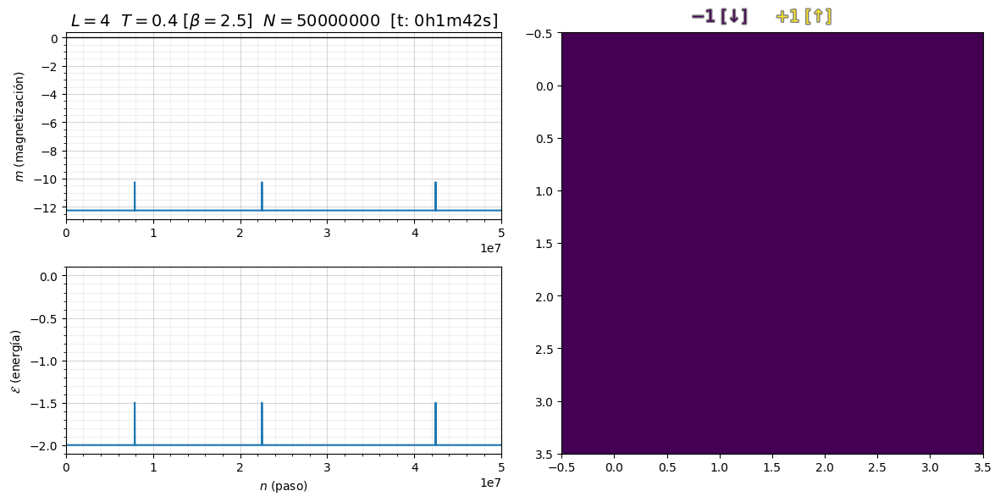


L = 4
T = 1.0 [β = 1.0]
N = 5000000

[t: 0h0m10s]



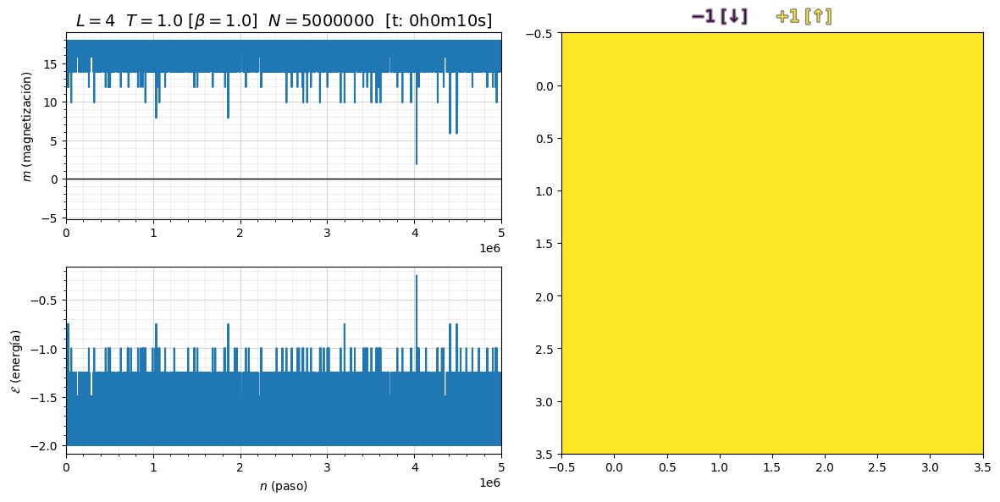


L = 4
T = 1.6 [β = 0.62]
N = 50000

[t: 0h0m0s]



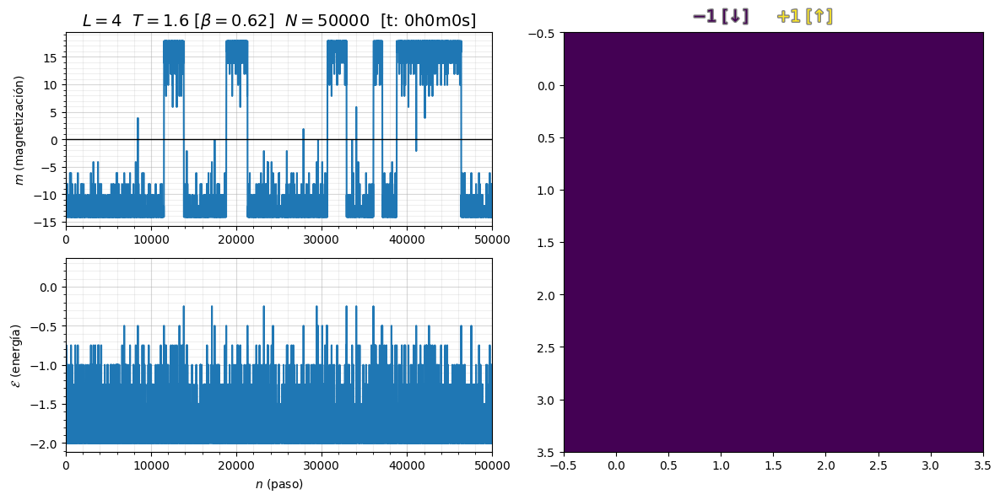


L = 4
T = 1.8 [β = 0.56]
N = 10000

[t: 0h0m0s]



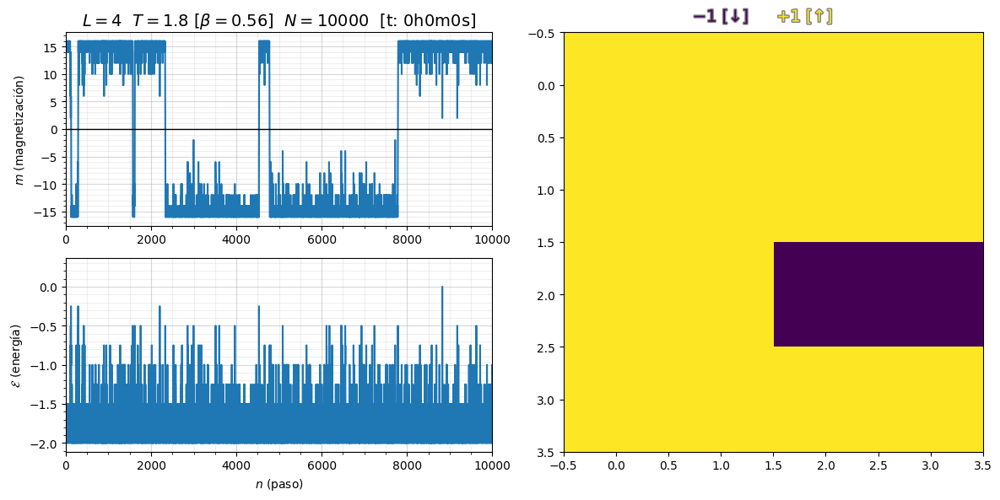


L = 4
T = 2.0 [β = 0.5]
N = 5000

[t: 0h0m0s]



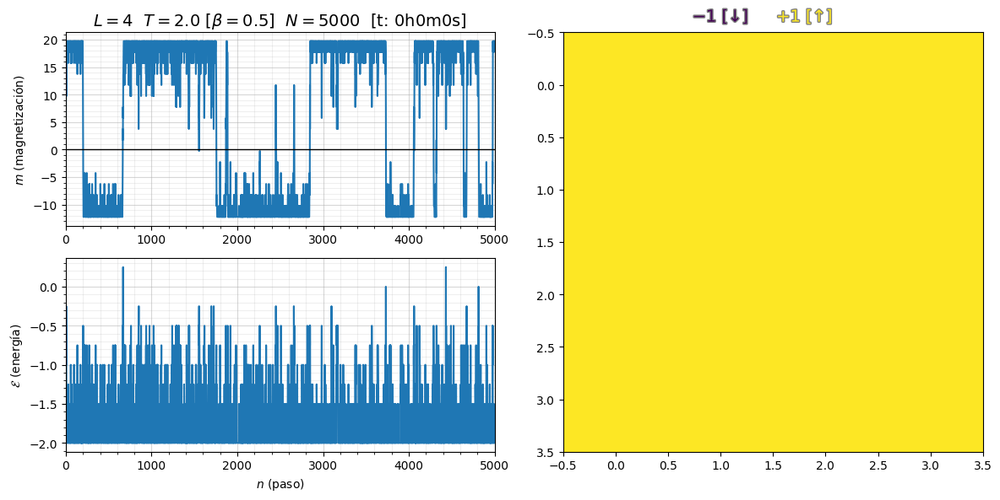


L = 4
T = 2.2 [β = 0.45]
N = 1000

[t: 0h0m0s]



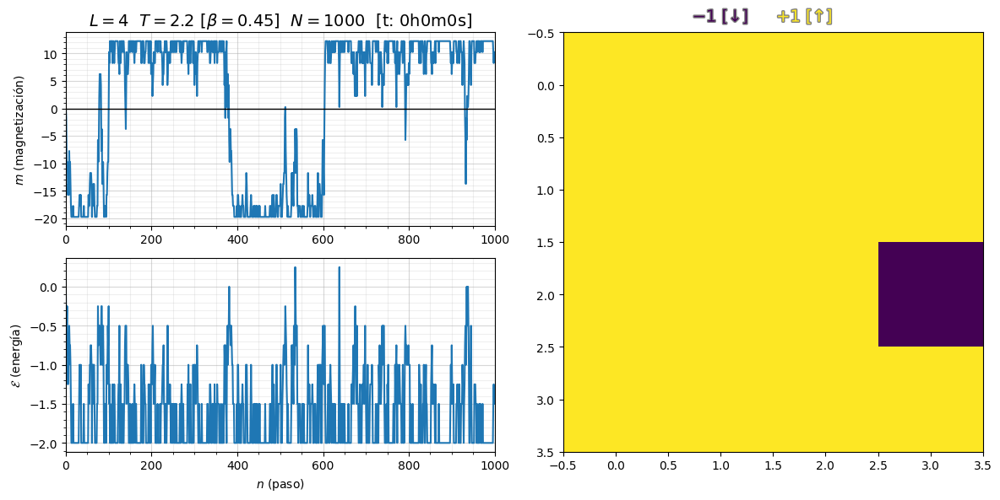


L = 4
T = 2.4 [β = 0.42]
N = 1000

[t: 0h0m0s]



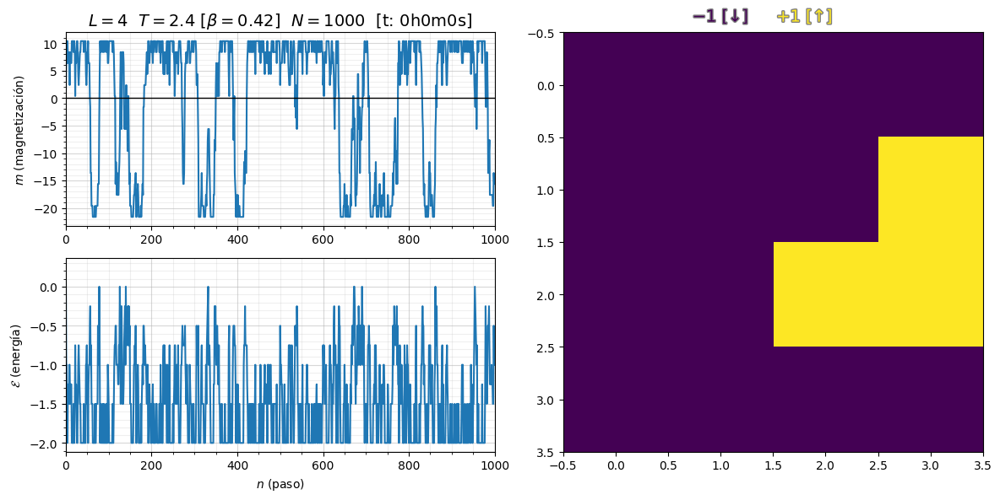


L = 4
T = 2.6 [β = 0.38]
N = 500

[t: 0h0m0s]



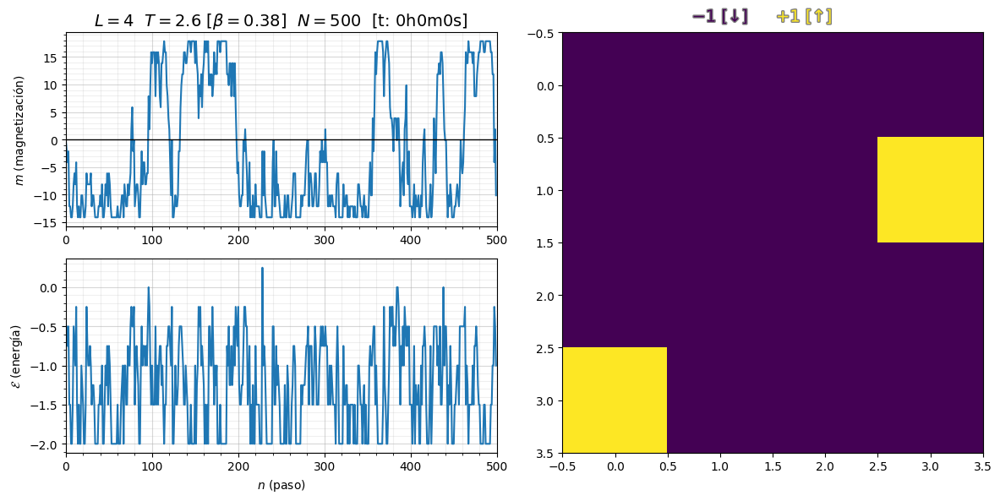


L = 4
T = 2.8 [β = 0.36]
N = 250

[t: 0h0m0s]



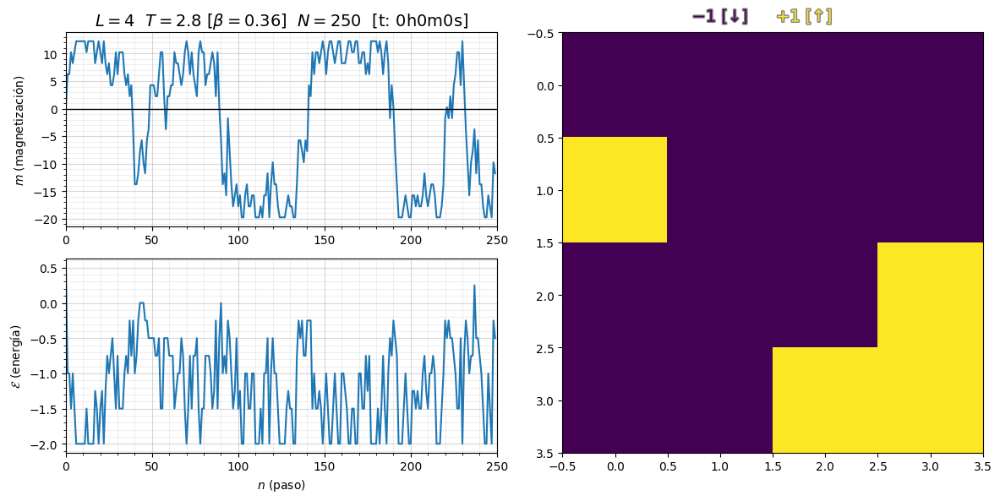


L = 4
T = 3.4 [β = 0.29]
N = 100

[t: 0h0m0s]



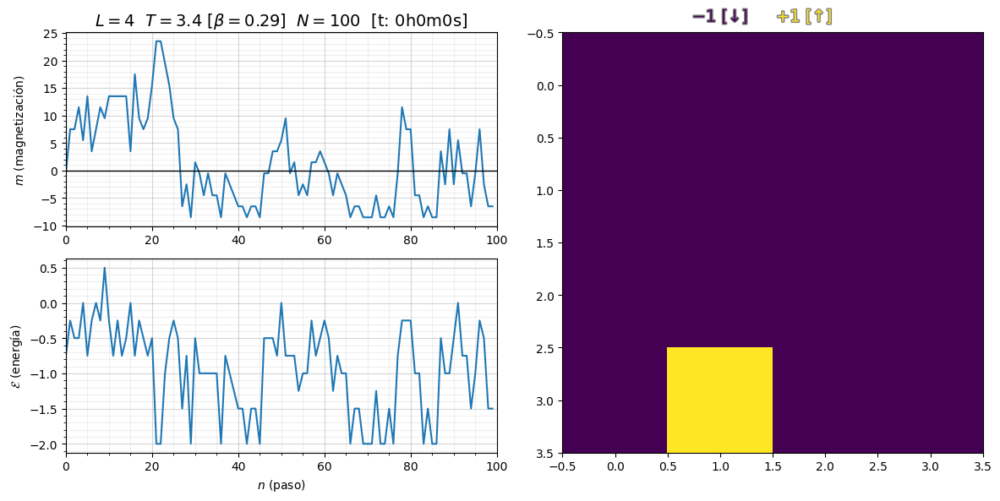


L = 4
T = 4.0 [β = 0.25]
N = 50

[t: 0h0m0s]



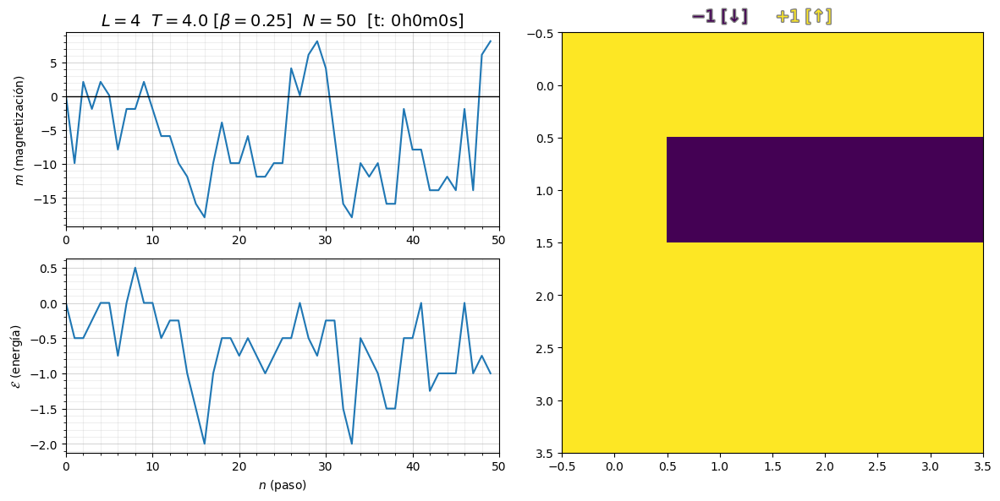


L = 4
T = 10.0 [β = 0.1]
N = 50

[t: 0h0m0s]



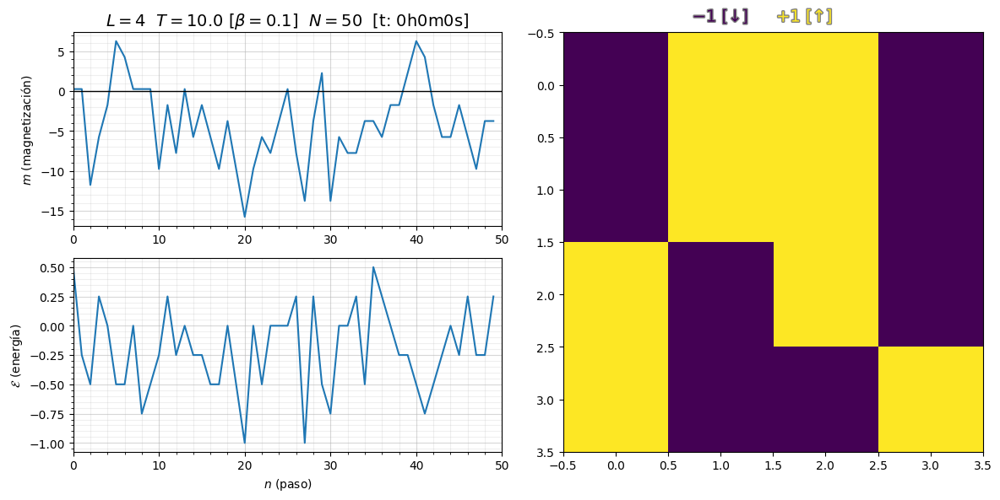

In [ ]:
L = 4

pares = [
    (0.4, 50000000),
    (1.0, 5000000),
    (1.6, 50000),
    (1.8, 10000),
    (2.0, 5000),
    (2.2, 1000),
    (2.4, 1000),
    (2.6, 500),
    (2.8, 250),
    (3.4, 100),
    (4.0, 50),
    (10.0, 50),
]

for T, N in pares:
    analizar_termalizacion(L, T, N, mostrar_progreso=True, graficar_chiquito=False, imprimir_matriz=False)


#### $L = 16$


L = 16
T = 0.4 [β = 2.5]
N = 1000000

[t = 0h0m26s]



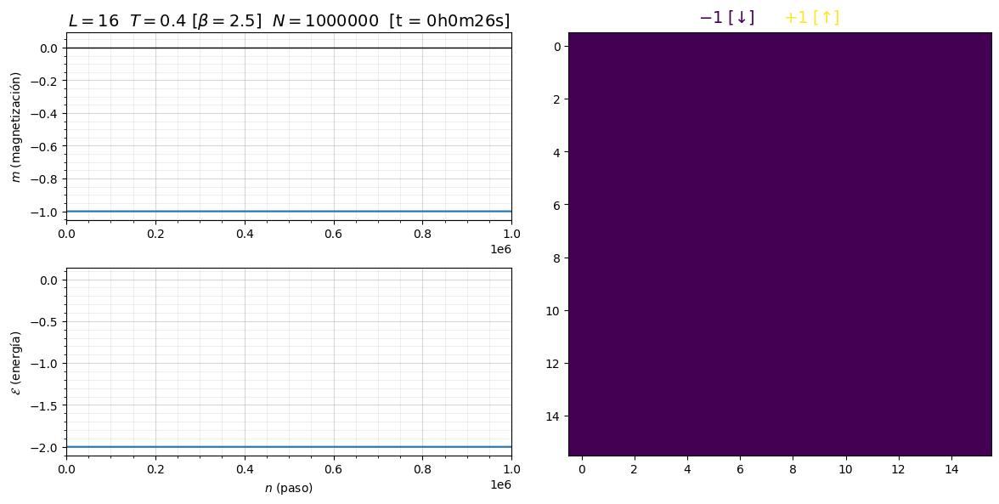


L = 16
T = 1.0 [β = 1.0]
N = 1000000

[t = 0h0m24s]



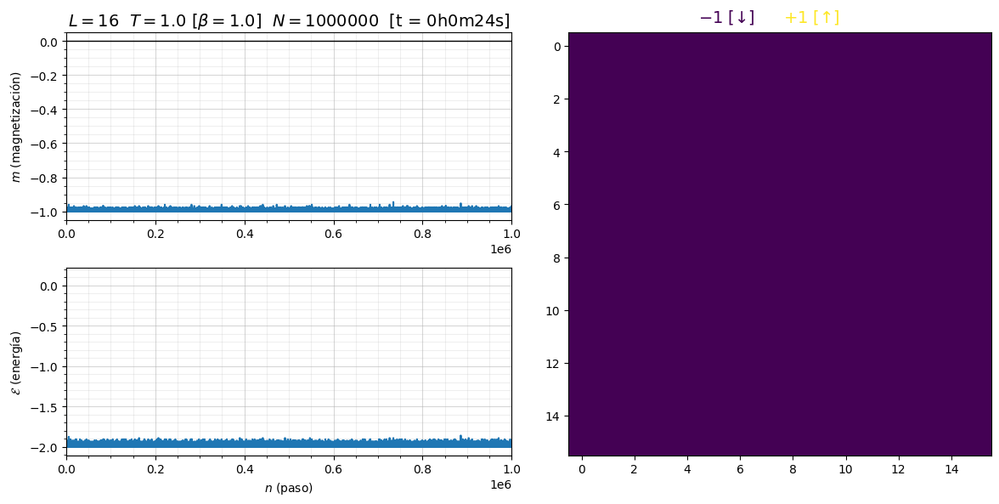


L = 16
T = 1.6 [β = 0.62]
N = 1000000

[t = 0h0m25s]



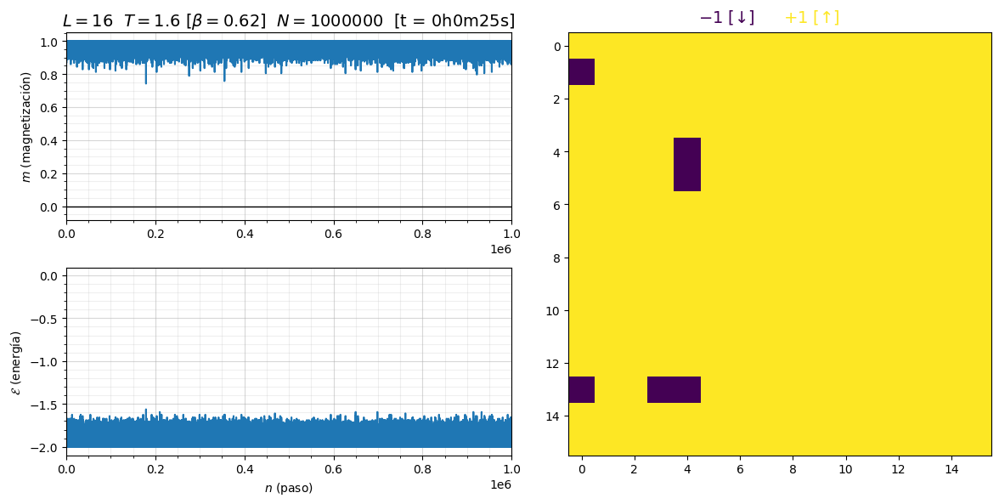


L = 16
T = 1.8 [β = 0.56]
N = 1000000

[t = 0h0m24s]



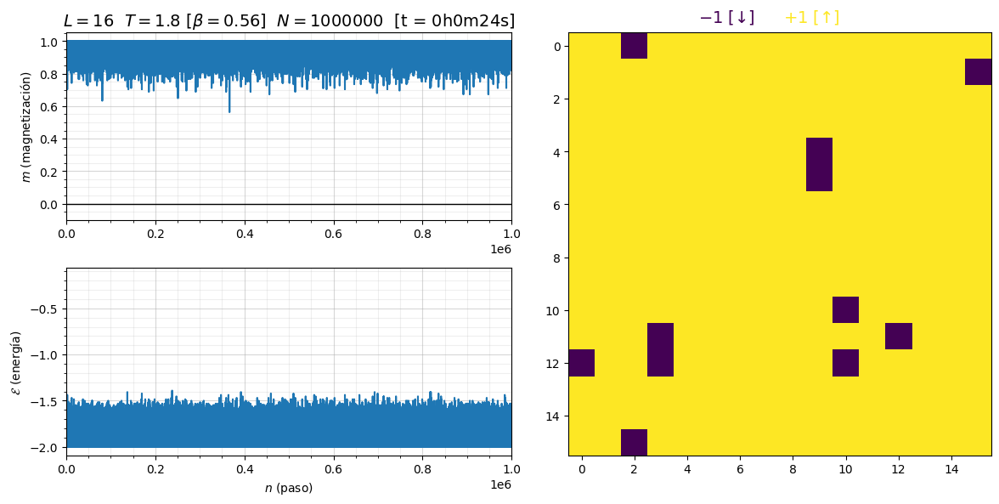


L = 16
T = 2.0 [β = 0.5]
N = 1000000

[t = 0h0m24s]



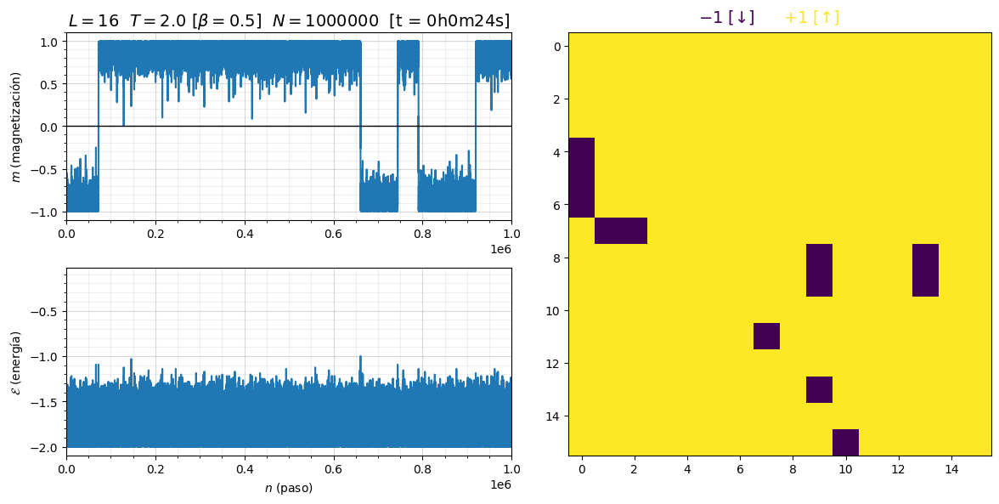


L = 16
T = 2.2 [β = 0.45]
N = 50000

[t = 0h0m1s]



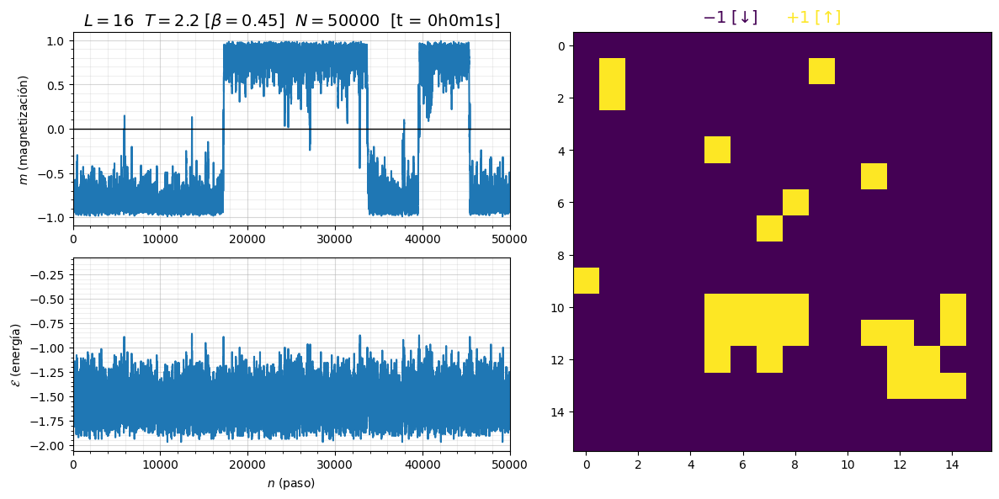


L = 16
T = 2.4 [β = 0.42]
N = 10000

[t = 0h0m0s]



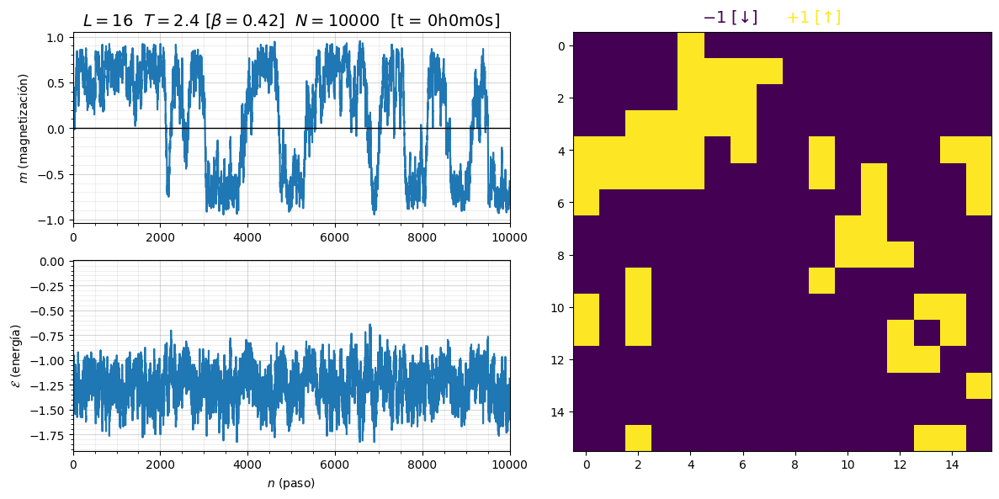


L = 16
T = 2.6 [β = 0.38]
N = 5000

[t = 0h0m0s]



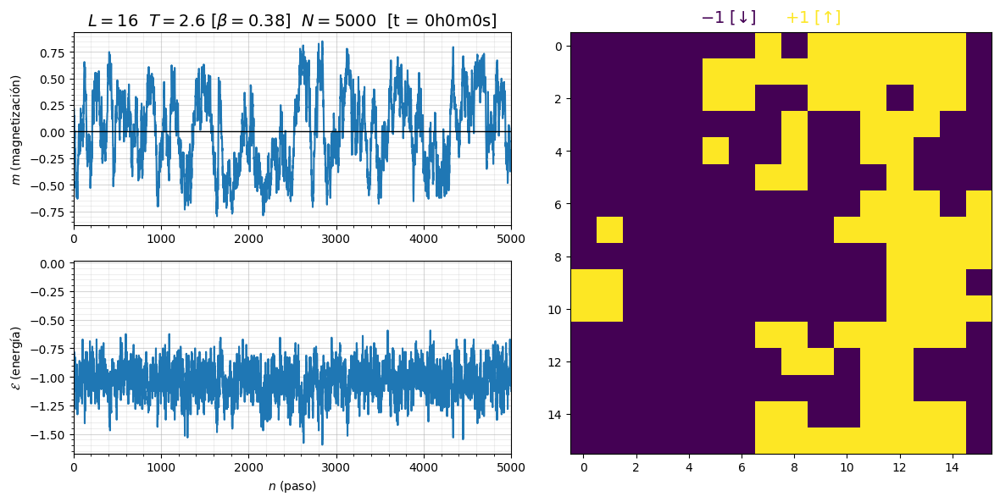


L = 16
T = 2.8 [β = 0.36]
N = 5000

[t = 0h0m0s]



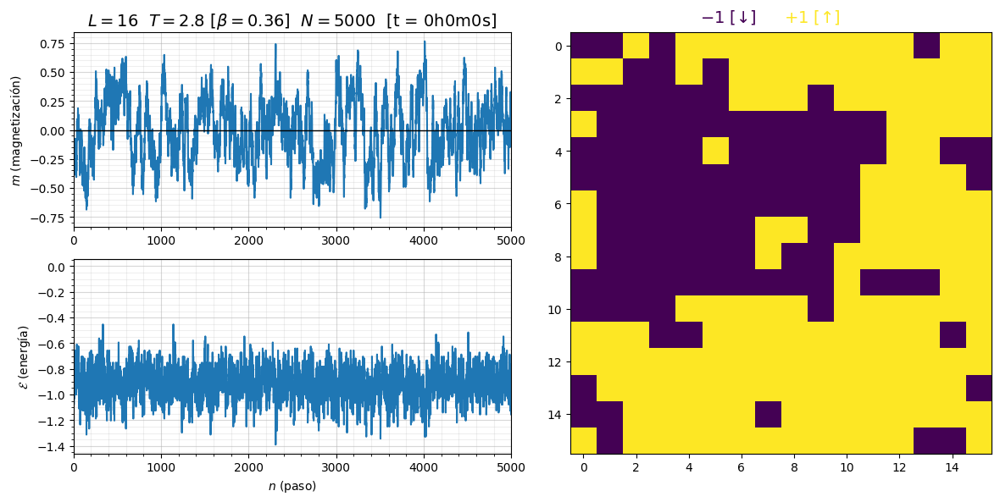


L = 16
T = 4.0 [β = 0.25]
N = 5000

[t = 0h0m0s]



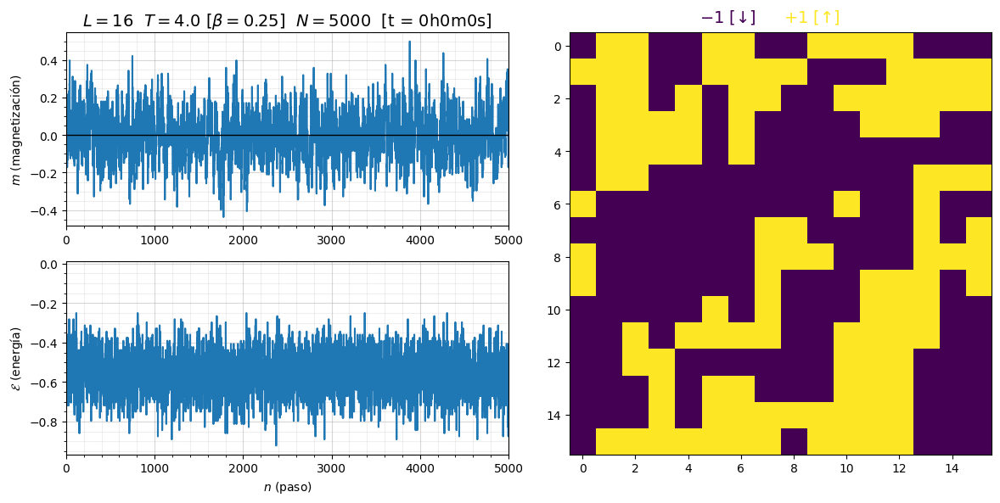


L = 16
T = 10.0 [β = 0.1]
N = 5000

[t = 0h0m0s]



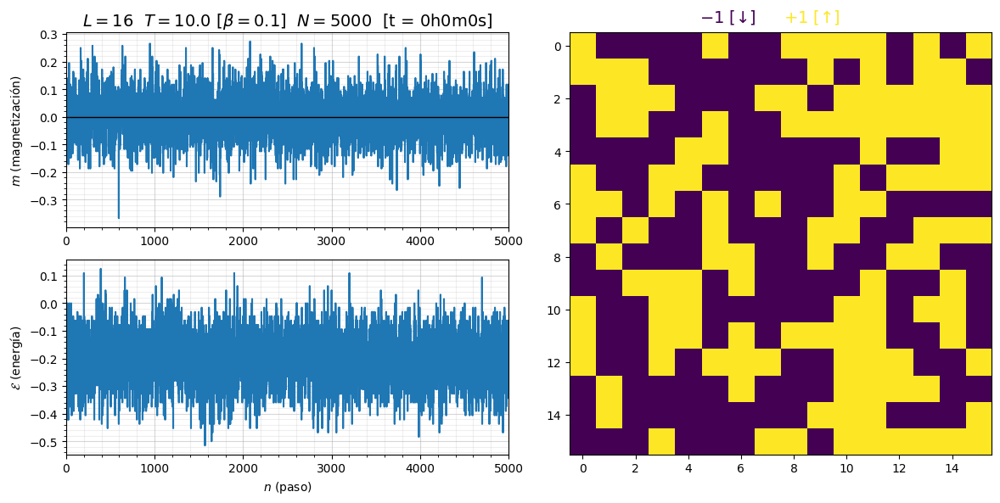

In [ ]:
L = 16

pares = [
    (0.4, 1000000),
    (1.0, 1000000),
    (1.6, 1000000),
    (1.8, 1000000),
    (2.0, 1000000),
    (2.2, 50000),
    (2.4, 10000),
    (2.6, 5000),
    (2.8, 5000),
    (4.0, 5000),
    (10.0, 5000),
]

for T, N in pares:
    analizar_termalizacion(L, T, N, graficar_chiquito=False)

### (2) For a fixed $T$, the period increases with $L$:

#### $T = 1$


L = 4
T = 1 [β = 1.0]
N = 20000000

[t: 0h0m35s]



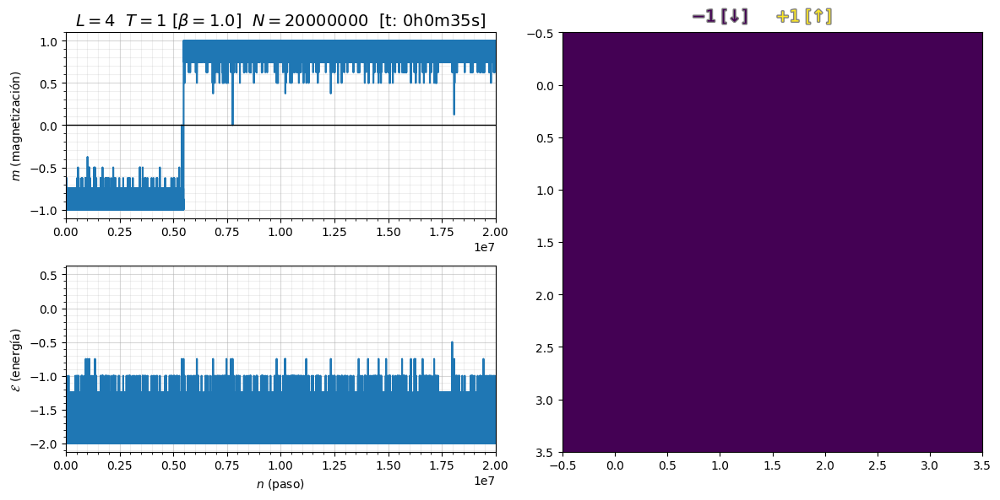


L = 8
T = 1 [β = 1.0]
N = 1000000

[t: 0h0m5s]



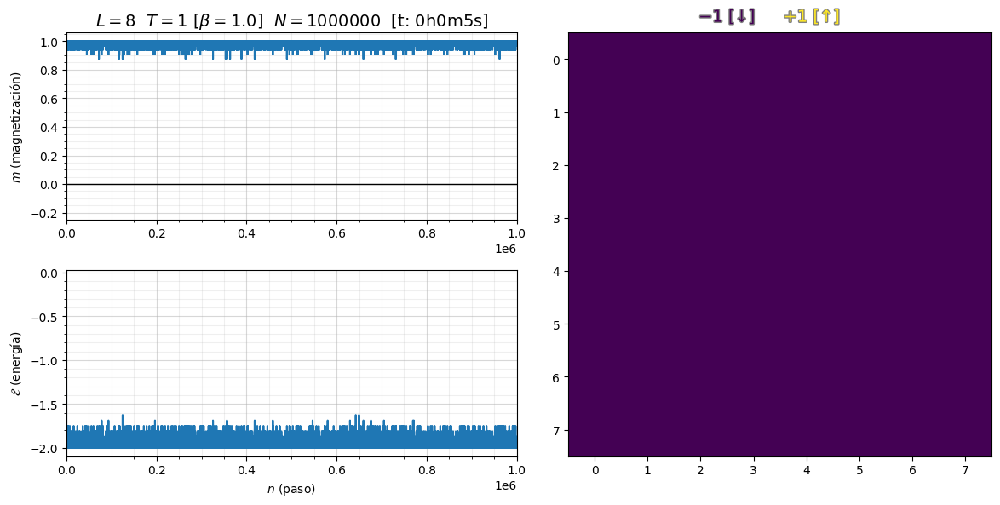


L = 16
T = 1 [β = 1.0]
N = 50000000

[t: 0h20m42s]



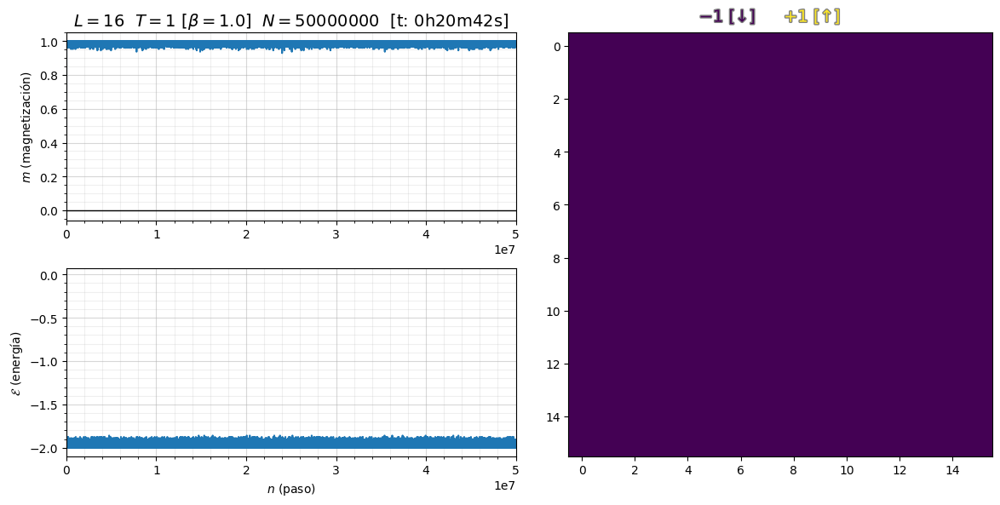

In [ ]:
T = 1

for L, N in [(4, 20000000), (8, 1000000), (16, 50000000)]:
    analizar_termalizacion(L, T, N, graficar_chiquito=False)


#### $T = 2$


L = 4
T = 2 [β = 0.5]
N = 5000

[t = 0h0m0s]



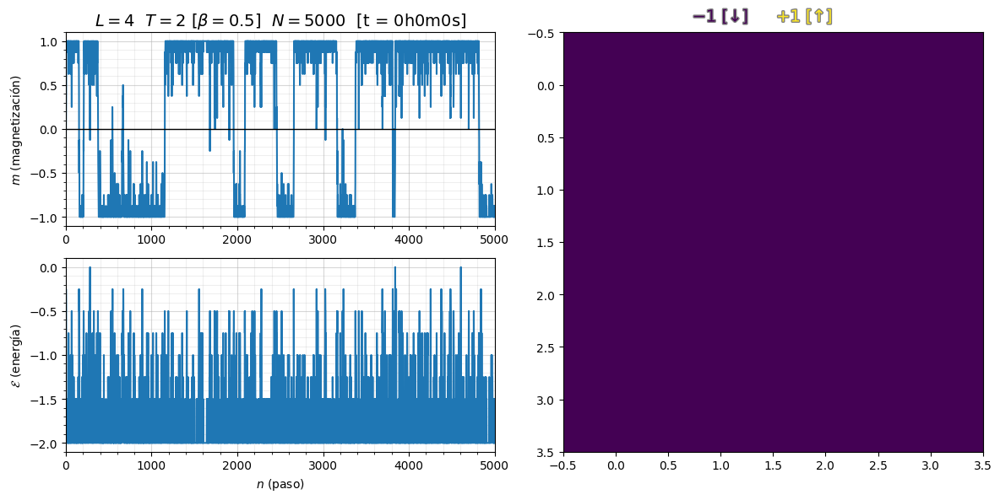


L = 8
T = 2 [β = 0.5]
N = 50000

[t = 0h0m0s]



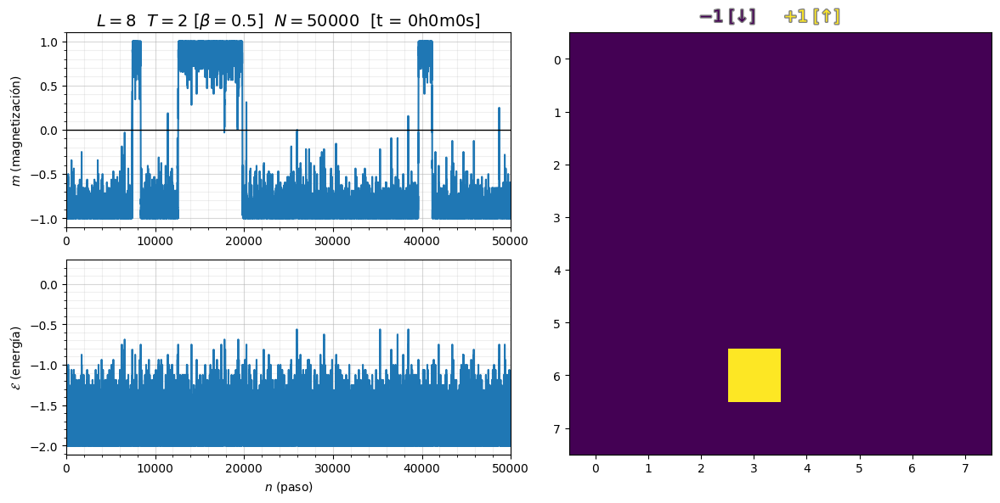


L = 16
T = 2 [β = 0.5]
N = 2000000

[t = 0h0m53s]



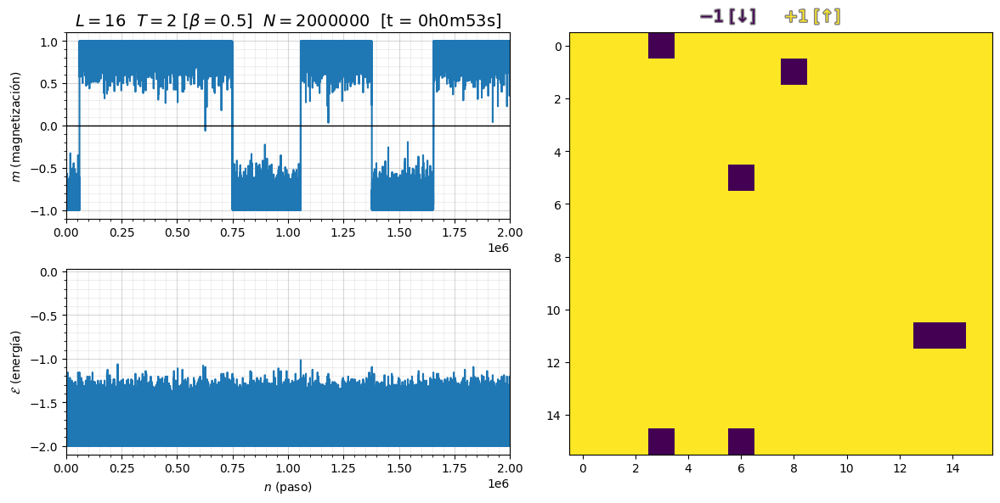

In [ ]:
T = 2

for L, N in [(4, 5000), (8, 50000), (16, 2000000)]:
    analizar_termalizacion(L, T, N, graficar_chiquito=False)


# Simulations

## $L = 64$


L = 64
T = 1.0 [β = 1.0]
N = 2000



100%|██████████| 1999/1999 [03:43<00:00,  8.96it/s]


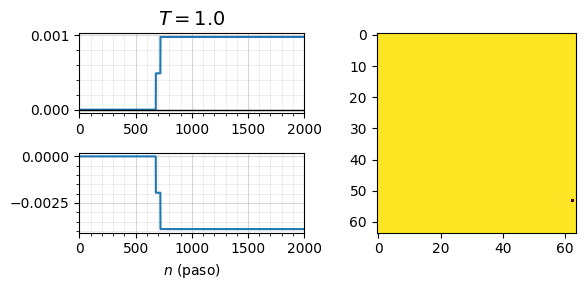


L = 64
T = 1.6 [β = 0.62]
N = 2000



100%|██████████| 1999/1999 [03:43<00:00,  8.96it/s]


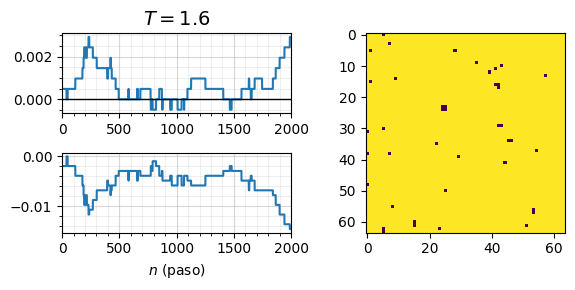


L = 64
T = 2.2 [β = 0.45]
N = 2000



100%|██████████| 1999/1999 [03:43<00:00,  8.93it/s]


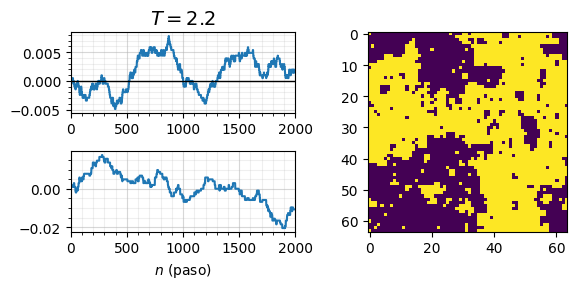


L = 64
T = 2.8 [β = 0.36]
N = 2000



100%|██████████| 1999/1999 [03:47<00:00,  8.80it/s]


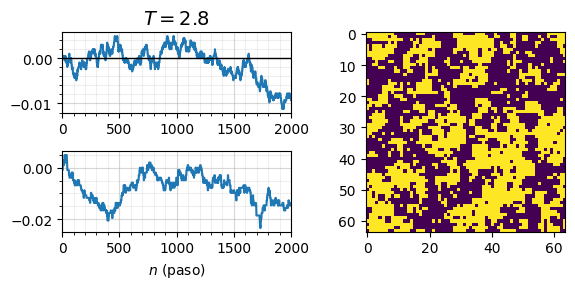


L = 64
T = 3.4 [β = 0.29]
N = 2000



100%|██████████| 1999/1999 [03:50<00:00,  8.69it/s]


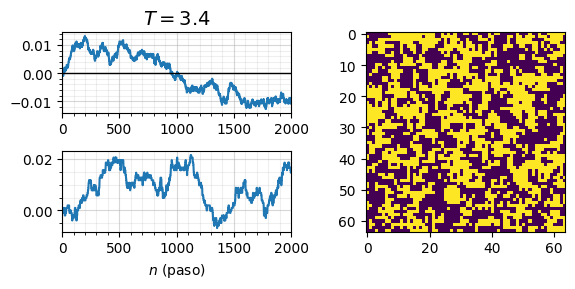


L = 64
T = 4.0 [β = 0.25]
N = 2000



100%|██████████| 1999/1999 [03:45<00:00,  8.86it/s]


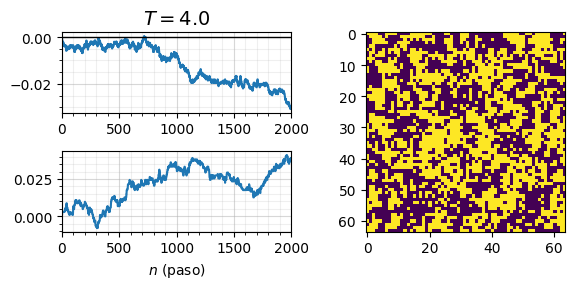

In [ ]:
L = 64
# Temperature, N pairs:
pares = [
    (1.5, 200),
    (1.8, 200),
    (2.1, 200),
    (2.4, 200),
    (2.7, 200),
    (3.0, 200),
]

for T, N in pares:
    analizar_termalizacion(L, T, N, graficar_chiquito=True)

## $L = 128$




L = 128
T = 0.4 [β = 2.5]
N = 10000

[t: 0h0m15s]



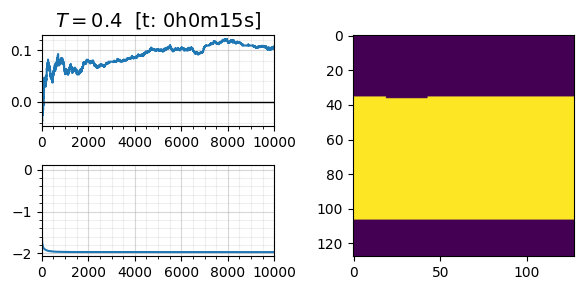


L = 128
T = 1.0 [β = 1.0]
N = 10000

[t: 0h0m15s]



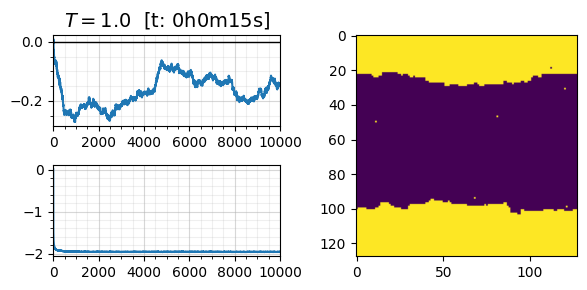


L = 128
T = 1.6 [β = 0.62]
N = 10000

[t: 0h0m16s]



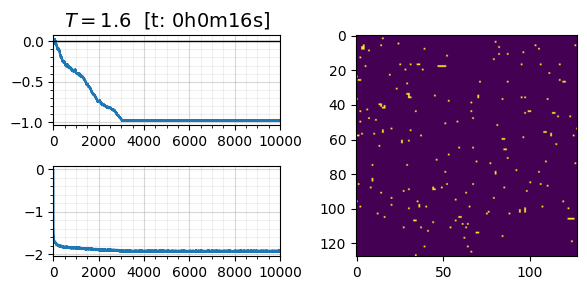


L = 128
T = 2.2 [β = 0.45]
N = 10000

[t: 0h0m15s]



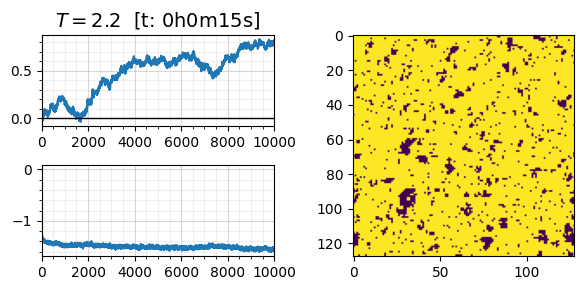


L = 128
T = 2.8 [β = 0.36]
N = 10000

[t: 0h0m15s]



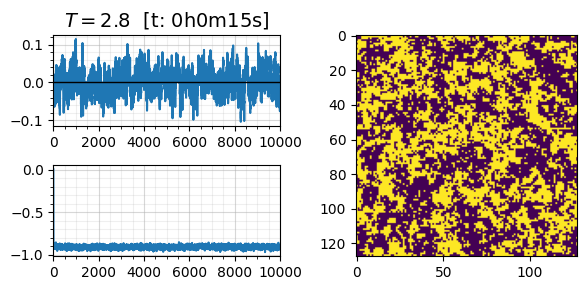


L = 128
T = 3.4 [β = 0.29]
N = 10000

[t: 0h0m17s]



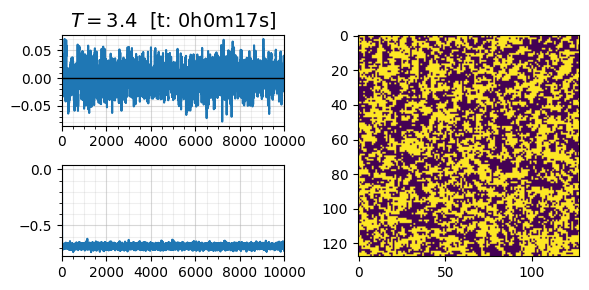


L = 128
T = 4.0 [β = 0.25]
N = 10000

[t: 0h0m15s]



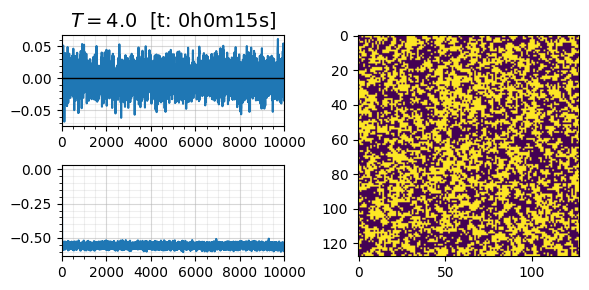


L = 128
T = 4.6 [β = 0.22]
N = 10000

[t: 0h0m15s]



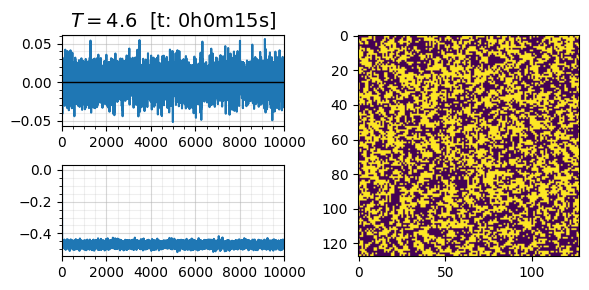


L = 128
T = 10 [β = 0.1]
N = 10000

[t: 0h0m15s]



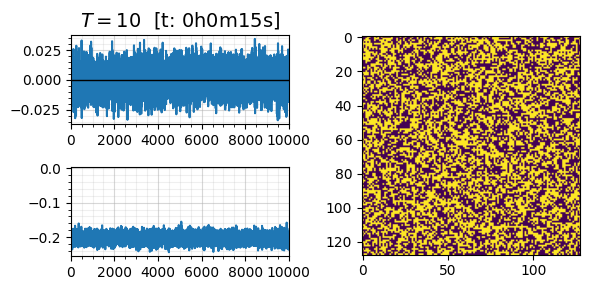

In [ ]:
L = 128
N = 10000

for T in [0.4, 1.0, 1.6, 2.2, 2.8, 3.4, 4.0, 4.6, 10]:
    analizar_termalizacion(L, T, N, graficar_chiquito=True)


L = 128
T = 1 [β = 1.0]
N = 10000

[t: 0h0m16s]



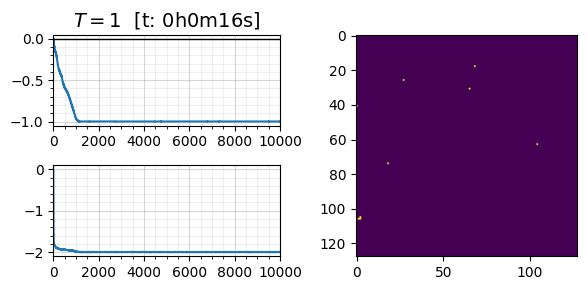


L = 128
T = 1.6 [β = 0.62]
N = 10000

[t: 0h0m16s]



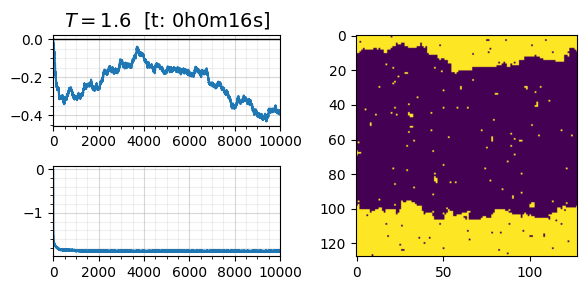


L = 128
T = 2.2 [β = 0.45]
N = 50000

[t: 0h1m19s]



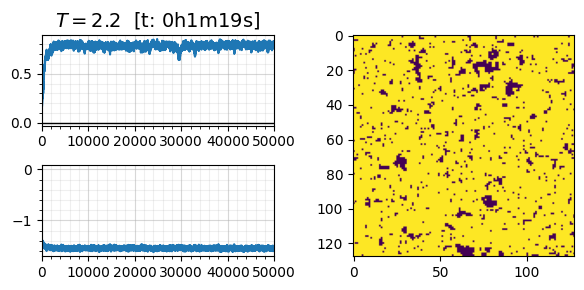


L = 128
T = 2.8 [β = 0.36]
N = 100000

[t: 0h2m39s]



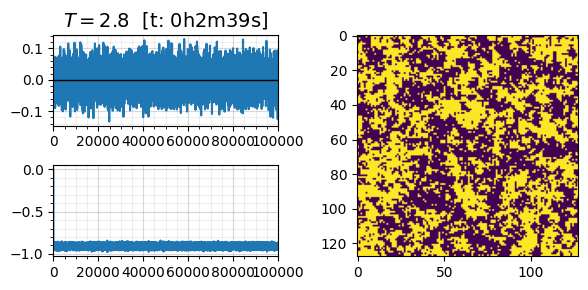


L = 128
T = 3.4 [β = 0.29]
N = 500000

[t: 0h13m24s]



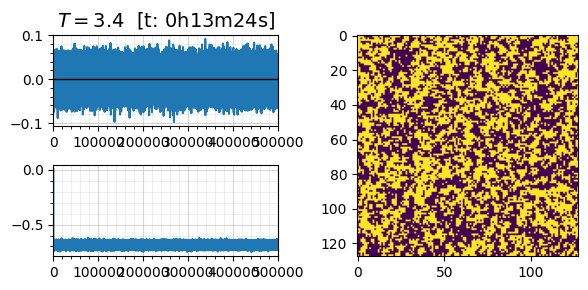


L = 128
T = 4 [β = 0.25]
N = 1000000

[t: 0h26m55s]



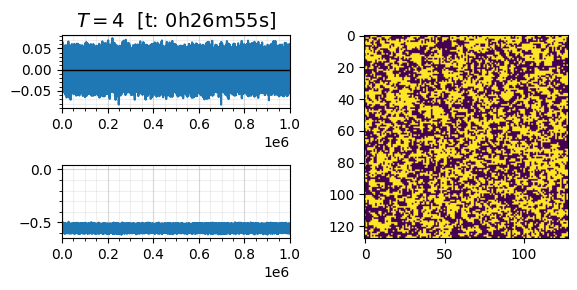

In [ ]:
L = 128

pares = [
    (1, 10000),
    (1.6, 10000),
    (2.2, 50000),
    (2.8, 100000),
    (3.4, 500000),
    (4, 1000000)
]

for T, N in pares:
    analizar_termalizacion(L, T, N, graficar_chiquito=True)

In [ ]:
L = 128

pares = [
    # (1.0, 1000000),
    # (1.6, 500000),
    (1.9, 10000),
    (2.0, 5000),
    (2.1, 500),
    (2.2, 100),
    (2.3, 25),
    (2.4, 10),
    (2.5, 5),
    # (3.4, 500),
    # (4, 10000000)
]

for T, N in pares:
    analizar_termalizacion(L, T, N, graficar_chiquito=True)


## $L = 256$


L = 256
T = 1.6 [β = 0.62]
N = 25000



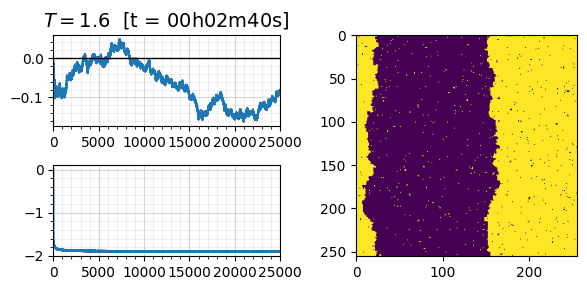


L = 256
T = 2.2 [β = 0.45]
N = 25000



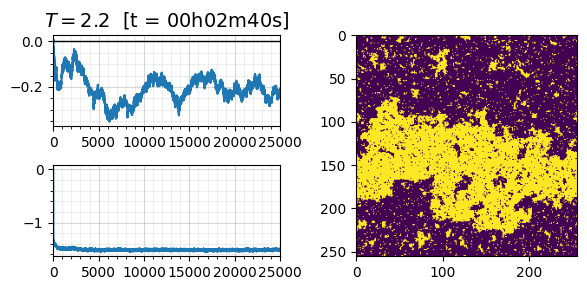

In [ ]:
L = 256

# Temperature, N pairs:
pares = [
    (1.6, 25000),
    (2.2, 25000)
]

for T, N in pares:
    analizar_termalizacion(L, T, N, graficar_chiquito=True)

## $L = 1024$


L = 1024
T = 0.4 [β = 2.5]
N = 500

[t = 0h2m0s]



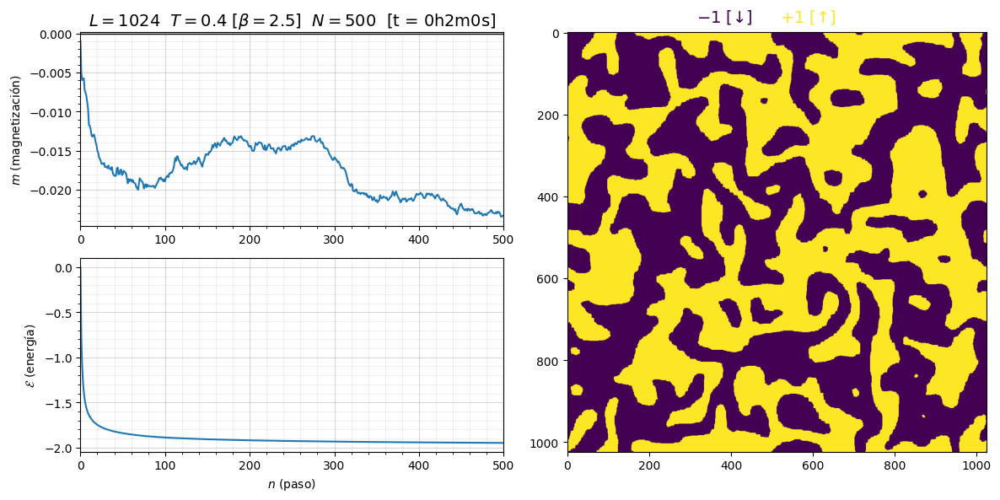


L = 1024
T = 1.0 [β = 1.0]
N = 500

[t = 0h1m49s]



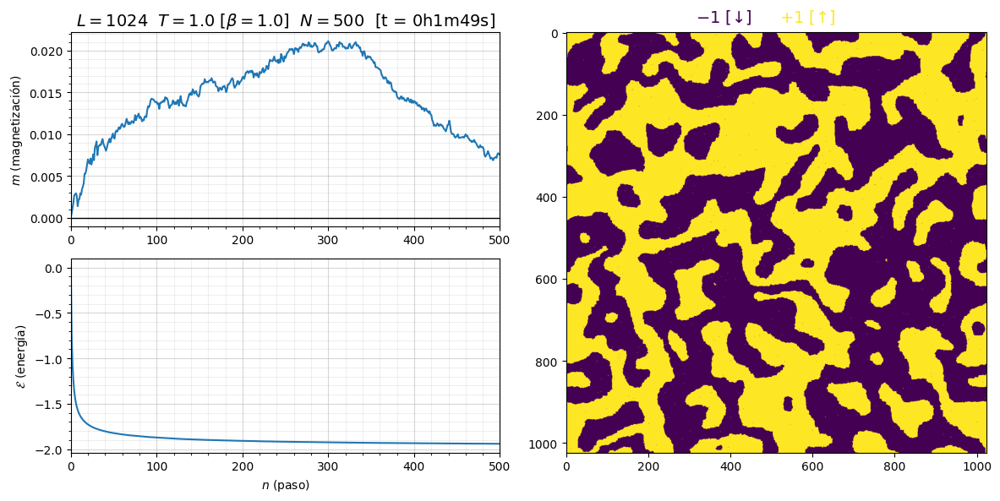


L = 1024
T = 1.6 [β = 0.62]
N = 500

[t = 0h1m51s]



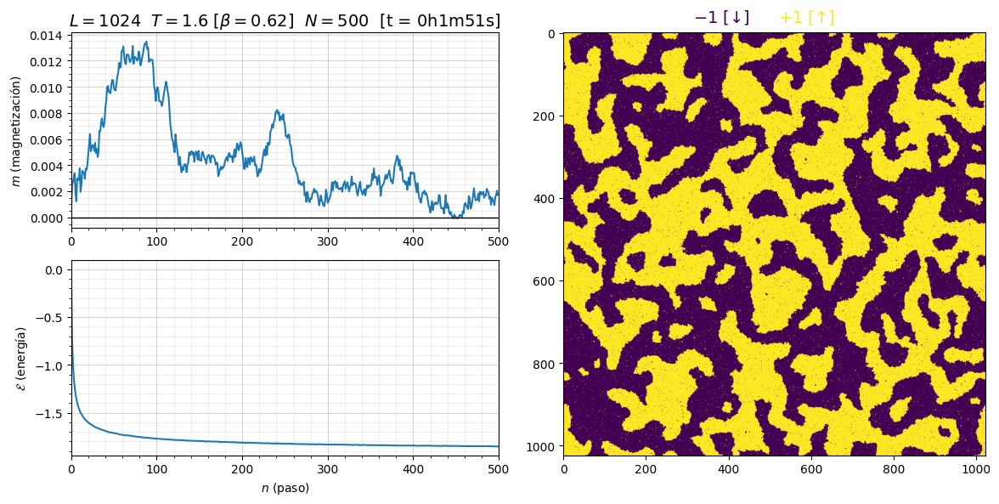


L = 1024
T = 2.2 [β = 0.45]
N = 500

[t = 0h2m17s]



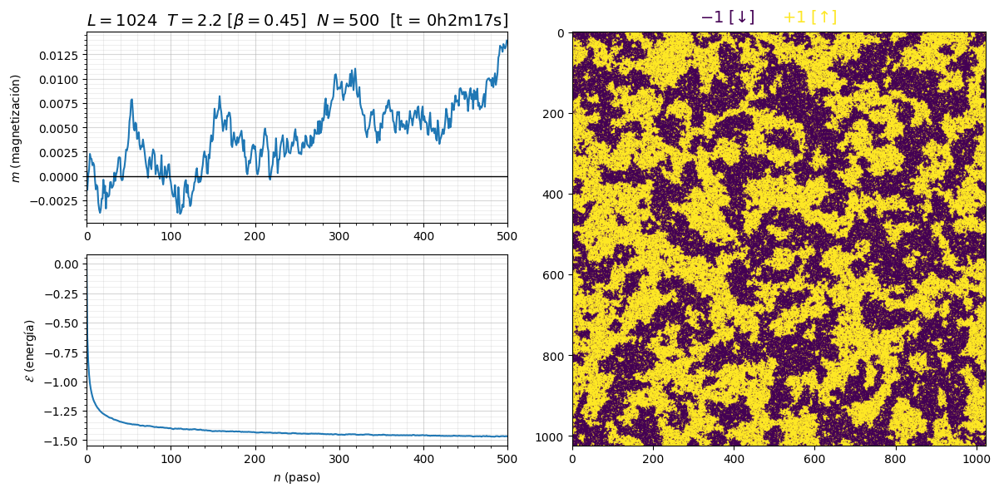


L = 1024
T = 2.8 [β = 0.36]
N = 500

[t = 0h2m2s]



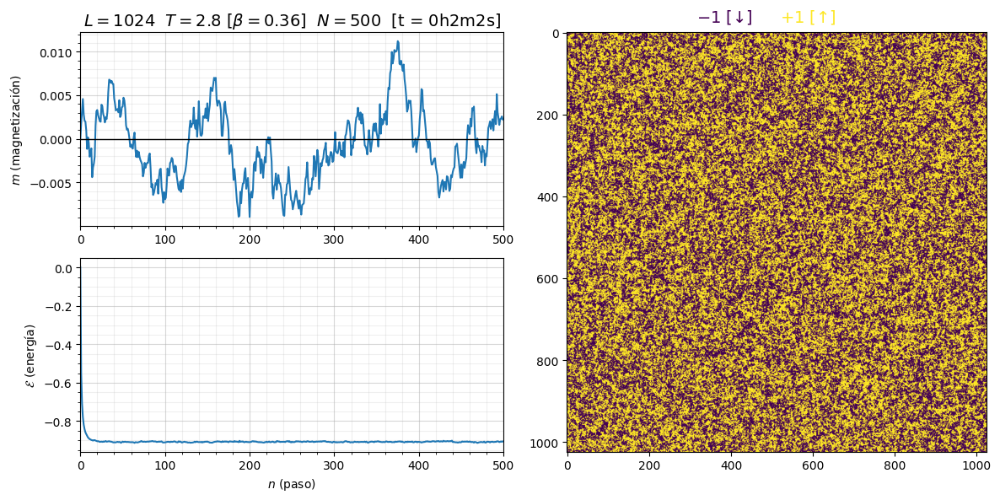


L = 1024
T = 3.4 [β = 0.29]
N = 500

[t = 0h1m54s]



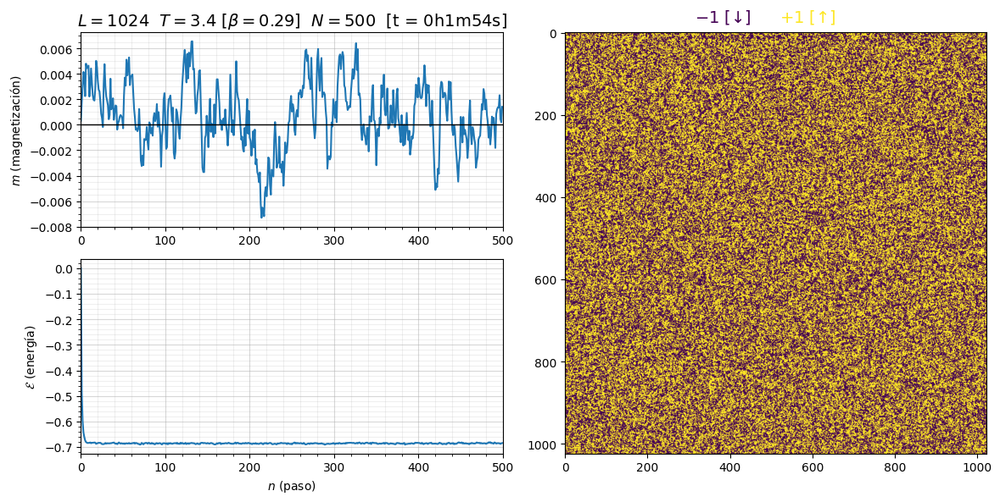


L = 1024
T = 4.0 [β = 0.25]
N = 500

[t = 0h1m50s]



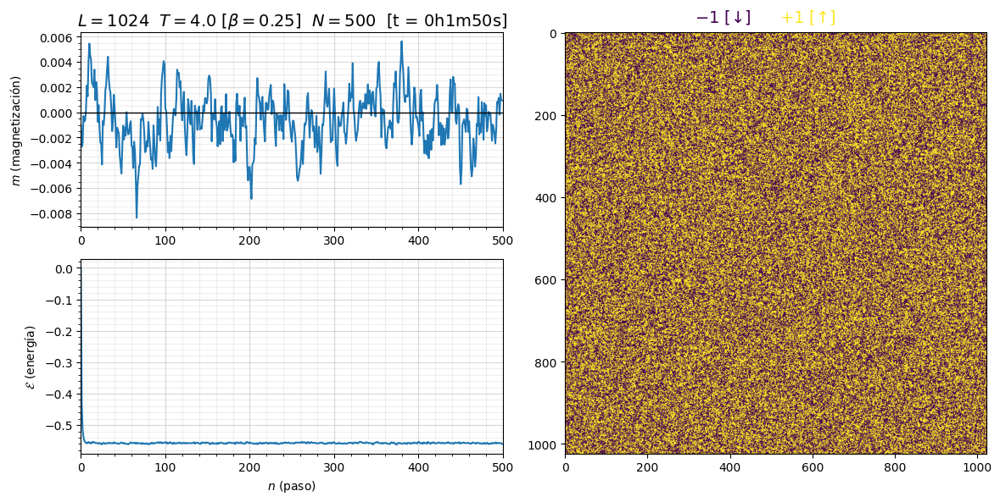


L = 1024
T = 4.6 [β = 0.22]
N = 500

[t = 0h1m49s]



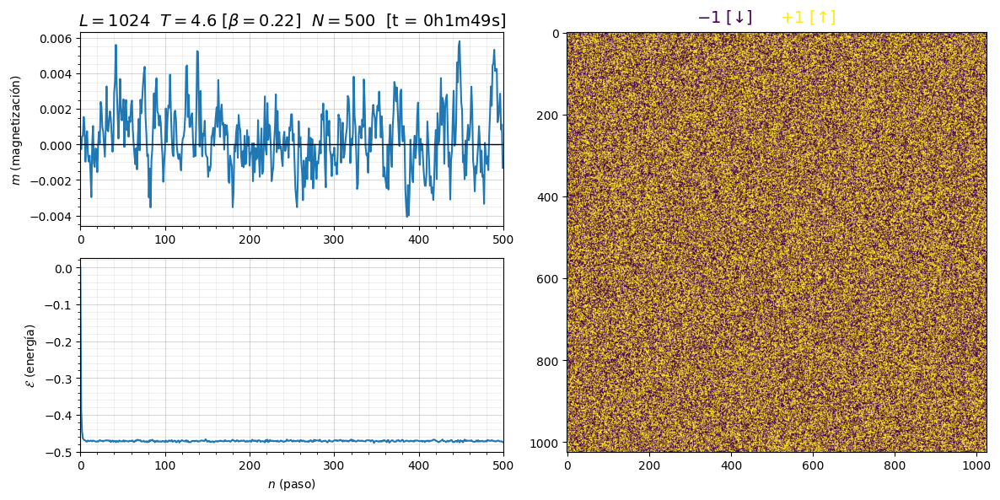


L = 1024
T = 10 [β = 0.1]
N = 500

[t = 0h1m49s]



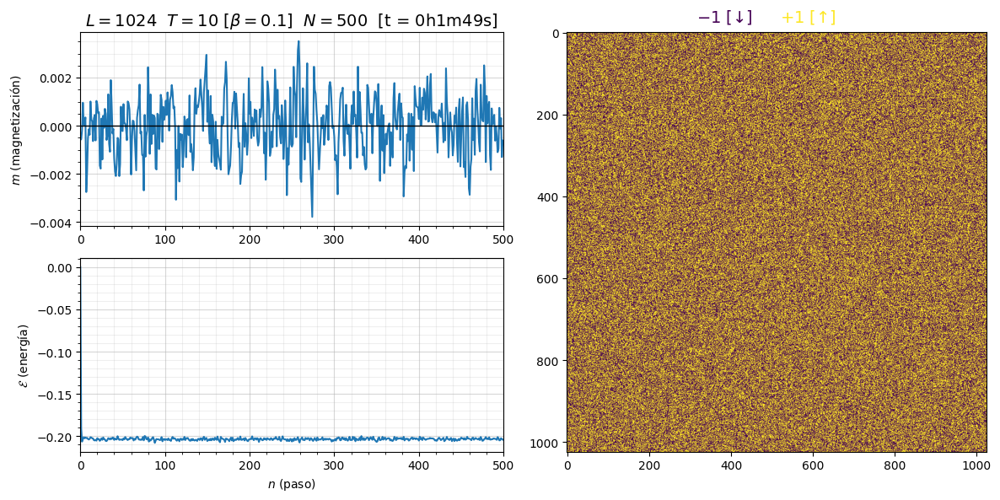

In [ ]:
L = 1024
N = 500

for T in [0.4, 1.0, 1.6, 2.2, 2.8, 3.4, 4.0, 4.6, 10]:
    analizar_termalizacion(L, T, N, graficar_chiquito=False)

# Averages

100%|██████████| 999/999 [00:00<00:00, 6371.55it/s]


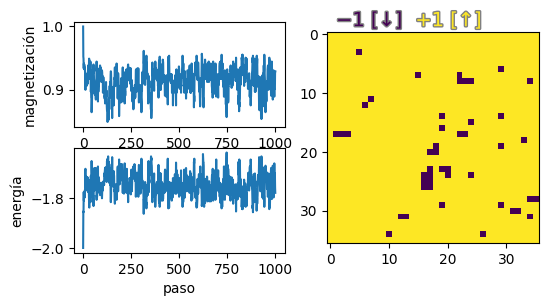

In [ ]:
L =  36                                                                           # Lattice size
T = 2                                                                            # T ranges from 1 to 4

beta = 1/T                                                                         # Inverse temperature for the simulation

nequilibrio = 1000                                                                # Tentative number of steps to reach equilibrium

prob = np.zeros(9)                                                                 # Transition probability vector
prob[4]=np.exp(-4 * beta)
prob[8]=np.exp(-8 * beta)
                                                                                # Initial state

S = np.ones((L, L), dtype = int)                                                   # Option 1: all spins point up at low temperature
#S = 2 * np.random.randint(2, size = (L, L)) - 1                                    # Option 2: random matrix of 1s and -1s at high temperature


m = np.zeros(nequilibrio)                                                         # Magnetization as a function of step
e = np.zeros(nequilibrio)                                                         # Energy as a function of step
m[0] = np.mean(S)                                                                 # Initial values
e[0] = h(S)

for n in tqdm(range(1, nequilibrio)):                                           # Run nequilibrio Monte Carlo steps
  S, dm, de = metropolis(S, prob)                                                 # Apply one Monte Carlo sweep
  m[n] = m[n - 1] + dm
  e[n] = e[n - 1] + de


plt.figure(figsize=(6, 3))                                                      # Plot the final state and the evolution of magnetization and energy per spin
plt.subplot(2, 2, 1)
plt.plot(m)

plt.ylabel('magnetization')
plt.subplot(2, 2, 3)
plt.plot(e)
plt.ylabel('energy')
plt.xlabel('step')

plt.subplot(1, 2, 2)
plt.text(0.20, 1.0255, '$-1$ [↓]', color=viridis(0.0),
         fontsize=14, ha="center",
         transform=plt.gca().transAxes,           # IMPORTANT
         path_effects=[pe.withStroke(linewidth=2, foreground='#808080')])

plt.text(0.5750, 1.0255, '$+1$ [↑]', color=viridis(1.0),
         fontsize=14, ha="center",
         transform=plt.gca().transAxes,
         path_effects=[pe.withStroke(linewidth=2, foreground='#808080')])
plt.imshow(S, cmap=plt.cm.colors.ListedColormap([viridis(0.0), viridis(1.0)]),
           vmin=-1, vmax=1)

plt.show()

100%|██████████| 5999/5999 [00:01<00:00, 3106.89it/s]


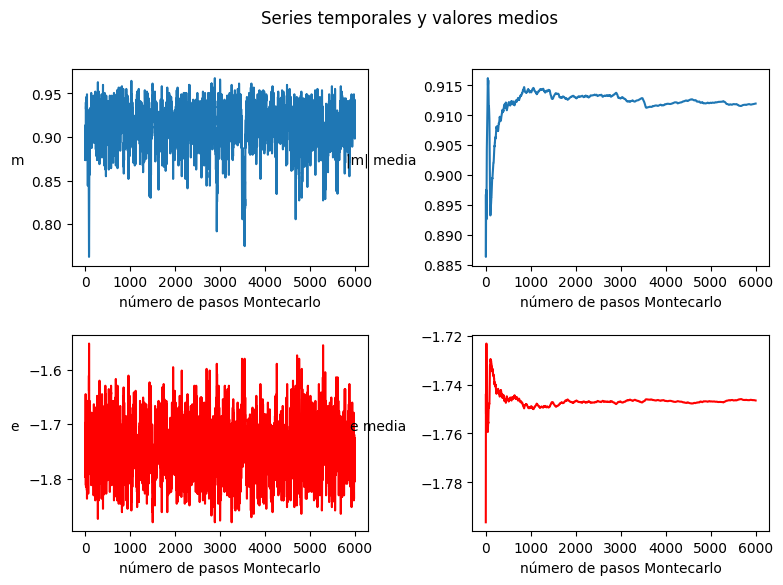

In [ ]:
L = 36
L2 = L * L
T= 2
beta = 1 / T

Nequilibrio = 1000                                                               # Value chosen based on the previous results
npromedio = 6000                                                                 # Tentative number of steps for calculating averages

prob = np.zeros(9)
prob[4]=np.exp(-4 * beta)
prob[8]=np.exp(-8 * beta)

S = np.ones((L, L), dtype = int)                                                 # Initial state
#S = 2 * np.random.randint(2, size = (L, L)) - 1

S = metropolisTermo(S, prob, Nequilibrio)                                        # Thermalization

m = np.zeros(npromedio)                                                          # Magnetization and energy as functions of the step
e = np.zeros(npromedio)

m[0] = np.mean(S)                                                                 # Initial values
e[0] = h(S)

mmedia = [abs(m[0])]                                                              # Running averages of absolute magnetization and energy
emedia = [e[0]]

# Generate time series and update the running averages at each step
for n in tqdm(range(1, npromedio)):
    S, dm, de = metropolis(S, prob)
    m[n] = m[n - 1] + dm
    e[n] = e[n - 1] + de
    mmedia.append((n * mmedia[n - 1] + abs(m[n])) / (n + 1))
    emedia.append((n * emedia[n - 1] + e[n]) / (n + 1))

m = m
e = e
mmedia = np.array(mmedia)
emedia = np.array(emedia)

fig = plt.figure(figsize = (9, 6))
plt.subplots_adjust(wspace = 0.35, hspace = 0.35)
fig.suptitle('Time series and running averages')
plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation = 0, labelpad = 10)
plt.xlabel('Monte Carlo steps')
plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('mean |m|', rotation = 0, labelpad = 30)
plt.xlabel('Monte Carlo steps')
plt.subplot(2, 2, 3)
plt.plot(e, color = 'red')
plt.ylabel('e', rotation = 0, labelpad = 10)
plt.xlabel('Monte Carlo steps')
plt.subplot(2, 2, 4)
plt.plot(emedia, color = 'red')
plt.ylabel('mean e', rotation = 0, labelpad = 30)
plt.xlabel('Monte Carlo steps')
plt.show()

100%|██████████| 43/43 [07:04<00:00,  9.87s/it]


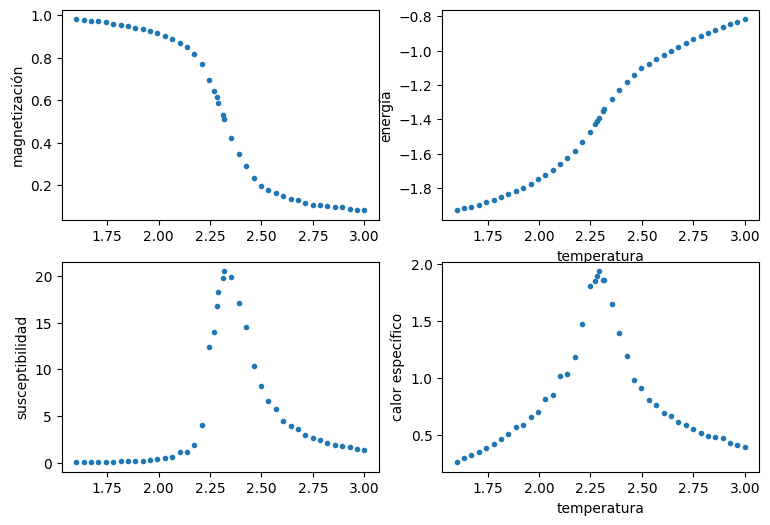

In [ ]:
L = 32                                                                            # Lattice size
L2 = L * L

Tini = 1.6
Tfinal = 3                                                                       # Define the temperature range
divisiones = 40                                                                  # Number of points to sample

centro = 2.291                                                                   # Approximate temperature at which chi is maximal
delta = 0.02   # width of the fine interval                                        # Define a narrow interval around the center, with more sample points
T_fino = np.linspace(centro - delta, centro + delta, 3)

T_grueso = np.linspace(Tini, Tfinal, divisiones)

temperaturas = np.unique(np.concatenate([T_grueso, T_fino]))                     # Temperature sweep, both away from and near the maximum
betas = 1 / temperaturas

factor = 5000                                                                      # Integer factor used to scale the total number of steps

nequilibriolejos = int(4* factor)                                                  # Use int in case a fraction of the factor is needed
npromediolejos = int(6 * factor)
nequilibriocerca = int(20 * factor)
npromediocerca= int(50 * factor)

mmedia = []                                                                       # Store measurements at each temperature
emedia = []
chi = []
c = []

S = np.ones((L, L), dtype = int)                                                # Start at low temperature
#S = 2 * np.random.randint(2, size = (L, L)) - 1
prob = np.zeros(9)

for beta in tqdm(betas):
  prob[4]=np.exp(-4 * beta)
  prob[8]=np.exp(-8 * beta)                                                     # Set this according to how dE maps to indices in the probability vector


  if abs(1 / beta - centro) < 0.08:                                              # Adjust the interval center to the location of the maximum for each L
    nequilibrio = nequilibriocerca                                              # Choose step counts according to the distance from the center
    npromedio = npromediocerca
  else:
    nequilibrio = nequilibriolejos
    npromedio = npromediolejos

  S = metropolisTermo(S, prob, nequilibrio)                                     # Thermalize the system

  S, m, e, varm, vare = metropolisN(S, prob, npromedio)                         # Measure mean absolute magnetization, mean energy,
                                                                                # and the variances of absolute magnetization and energy
  beta2 = beta*beta
  mmedia.append(m)                                                              # Store mean absolute magnetization per spin
  emedia.append(e)                                                              # Store mean energy per spin
  chi.append(beta * L2 * varm)                                                  # Calculate the susceptibility
  c.append(beta2 * L2 * vare)                                                   # Calculate the specific heat


plt.figure(figsize=(9, 6))                                                      # Plots
plt.subplot(2, 2, 1)
plt.scatter(temperaturas,mmedia,marker='.')
plt.ylabel('magnetization')
plt.subplot(2, 2, 2)
plt.scatter(temperaturas,emedia,marker='.')
plt.ylabel('energy')
plt.xlabel('temperature')
plt.subplot(2, 2, 3)
plt.scatter(temperaturas,chi,marker='.')
plt.ylabel('susceptibility')
plt.subplot(2, 2, 4)
plt.scatter(temperaturas,c,marker='.')
plt.ylabel('specific heat')
plt.xlabel('temperature')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


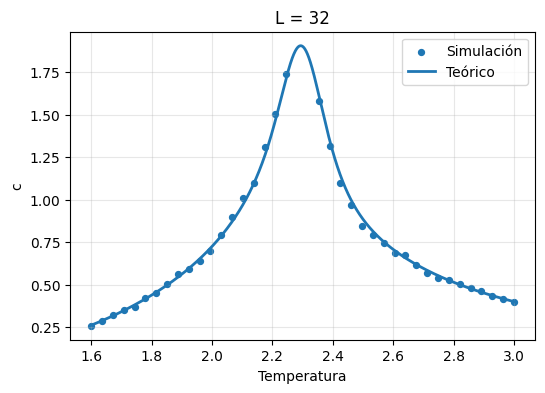

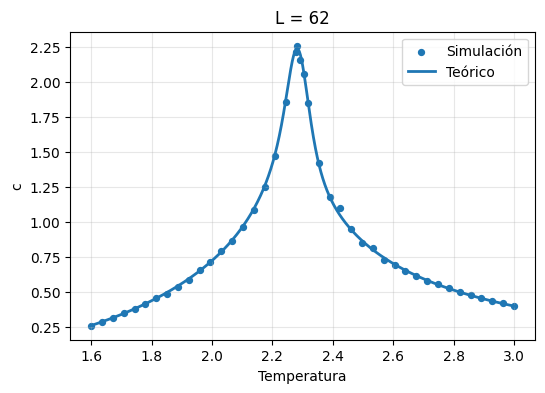

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')


folder = "/content/drive/MyDrive/Comparación teórica/"
files = os.listdir(folder)

# Extract all available lattice sizes (numbers only)
Ls = sorted({
    f.split('=')[1].split('.')[0].replace('_teorico', '')
    for f in files if f.startswith("L=")
})

for L in Ls:
    plt.figure(figsize=(6,4))

    fname_data = f"L={L}.txt"
    fname_teo  = f"L={L}_teorico.txt"

    # Simulated data
    if fname_data in files:
        data = np.loadtxt(folder + fname_data, delimiter=',')
        temps_data = data[:, 0]
        c_data = data[:, 1]
        plt.scatter(temps_data, c_data, s=18, label="Simulation")

    # Theoretical curve
    if fname_teo in files:
        data_teo = np.loadtxt(folder + fname_teo, delimiter=',')
        temps_teo = data_teo[:, 0]
        c_teo = data_teo[:, 1]
        plt.plot(temps_teo, c_teo, linewidth=2, label="Theory")

    plt.title(f"L = {L}")
    plt.xlabel("Temperature")
    plt.ylabel("c")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

# Critical temperature

100%|██████████| 20/20 [34:02<00:00, 102.10s/it]

[[2.34       8.77735779]
 [2.34368421 8.74269015]
 [2.34736842 8.80496049]
 [2.35105263 8.83574229]
 [2.35473684 8.98810529]
 [2.35842105 8.99882032]
 [2.36210526 8.97709909]
 [2.36578947 9.06828128]
 [2.36947368 8.9795971 ]
 [2.37315789 9.03078593]
 [2.37684211 9.07569323]
 [2.38052632 8.99572198]
 [2.38421053 8.98323246]
 [2.38789474 8.93080746]
 [2.39157895 8.8169034 ]
 [2.39526316 8.90215872]
 [2.39894737 8.86565116]
 [2.40263158 8.8006276 ]
 [2.40631579 8.77657335]
 [2.41       8.67651989]]
Data saved to: L=20.csv


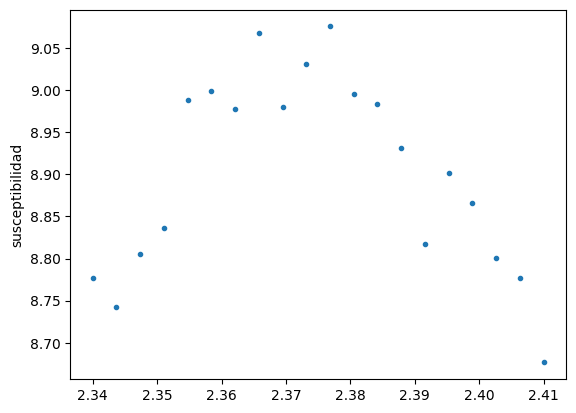

In [ ]:
L = 20
L2 = L * L

Tini = 2.34
Tfinal = 2.41
divisiones = 20

temperaturas = np.linspace(Tini, Tfinal, divisiones)
betas = 1 / temperaturas

factor = 100000
nequilibrio = 10 * factor
npromedio = 15 * factor

chi = []

# File where the data will be saved
filename = "L=20.csv"
f = open(filename, "w")
f.write("T,chi\n")        # Header

S = 2 * np.random.randint(2, size=(L, L)) - 1

for T, beta in tqdm(zip(temperaturas, betas), total=len(temperaturas)):

    prob = np.zeros(9)
    prob[4] = np.exp(-4 * beta)
    prob[8] = np.exp(-8 * beta)

    S = metropolisTermo(S, prob, nequilibrio)

    varm = metropolisChi(S, prob, npromedio, beta)

    chi.append(varm)

    # Write each result immediately
    f.write(f"{T},{varm}\n")
    f.flush()              # Ensure it is written to disk without affecting runtime

f.close()

plt.scatter(temperaturas, chi, marker='.')
plt.ylabel('susceptibility')

print(np.transpose([temperaturas, chi]))
print(f"Data saved to: {filename}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
For L = 100, T_c = 2.2934742717900023 ± 0.0007483871373060009
For L = 120, T_c = 2.290434798668165 ± 0.0010061145214668085
For L = 16, T_c = 2.4007676071456197 ± 0.0008811402095442133
For L = 20, T_c = 2.3739075348024836 ± 0.0010459115826595082
For L = 30, T_c = 2.3381276213912177 ± 0.0010638580566803438
For L = 75, T_c = 2.3004418734672867 ± 0.001199280909730593
For L = 90, T_c = 2.297473977280785 ± 0.0008244305186304506


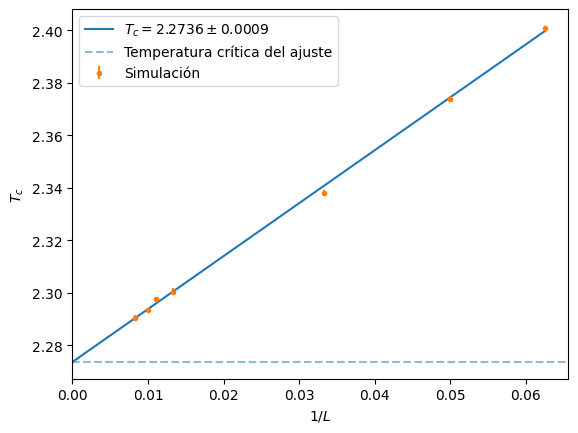

In [ ]:
folder = "/content/drive/MyDrive/Red cuadrada/"   # Folder containing the files

# Load all files named L=XX.txt
filenames = sorted([f for f in os.listdir(folder)
                    if f.startswith("L=") and f.endswith(".txt")])

temps = {}
chis = {}

for filename in filenames:
    data = np.loadtxt(folder + filename, delimiter=',')

    temp_label = filename.split('=')[1].split('.')[0]  # Extracts 16, 30, 75, ...
    temps[temp_label] = data[:, 0]
    chis[temp_label] = data[:, 1]


# Quadratic fit for each L
def cuad2(x, a, x_0, c):
    return a*(x - x_0)**2 + c

Ls = np.array([])
Tcs = np.array([])
sigmasTc = np.array([])

for L in temps.keys():
    temp, chi = temps[L], chis[L]
    popt, cov = curve_fit(cuad2, temp, chi, p0=[-30000, 0, 0])

    a, x_0, c = popt
    uncertainty_x_0 = np.sqrt(cov[1, 1])

    print(f"For L = {L}, T_c = {x_0} \u00b1 {uncertainty_x_0}")

    Ls = np.append(Ls, int(L))
    Tcs = np.append(Tcs, x_0)
    sigmasTc = np.append(sigmasTc, uncertainty_x_0)

# Linear fit
def lineal(x, a, b):
    return a*x + b

popt, cov = curve_fit(lineal, 1/Ls, Tcs, sigma=sigmasTc)

T_c = popt[1]
uncertainty_Tc = np.sqrt(cov[1, 1])


# Plot the results
x = np.linspace(100000, 16, 200)

plt.plot(1/x, lineal(1/x, *popt),
         label=f'$T_c = {T_c:.4f} \\pm {uncertainty_Tc:.4f}$')

plt.errorbar(1/Ls, Tcs, yerr=sigmasTc, fmt='.',label='Simulation')

plt.axhline(T_c, linestyle='--', alpha=0.5, label='Critical temperature from the fit')

plt.xlabel("$1/L$")
plt.ylabel("$T_c$")
plt.xlim(0, None)
plt.legend()
plt.show()

# Hexagonal lattice

## Hexagonal lattice transformation

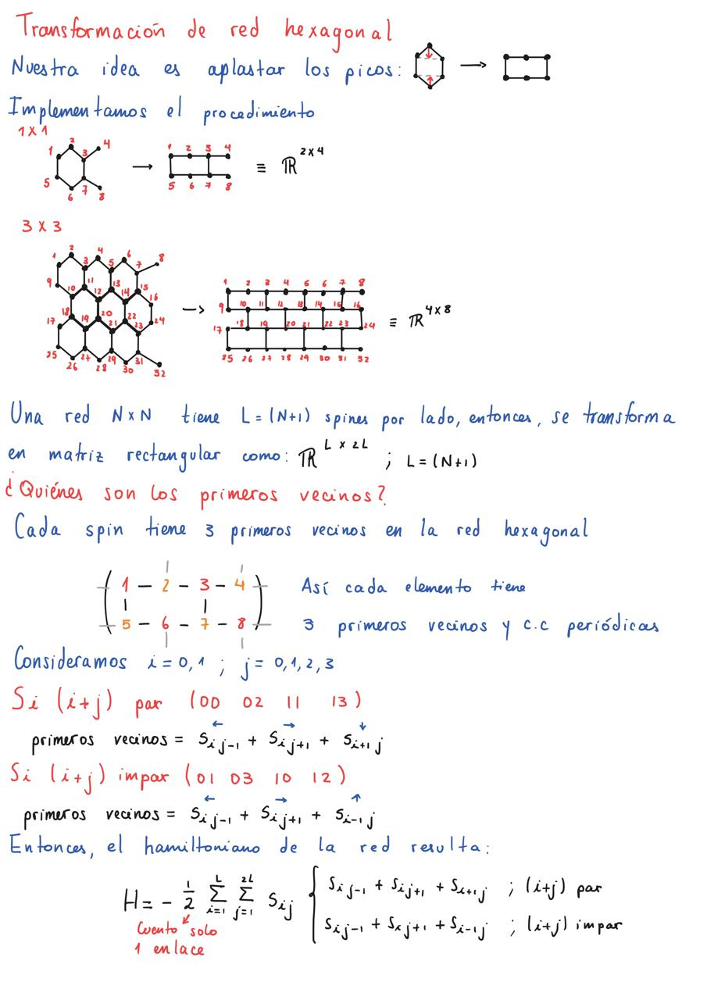

## Basic functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.optimize import curve_fit
from tqdm import tqdm
import time
import matplotlib.cm as cm
import matplotlib.patheffects as pe
viridis = cm.viridis

In [ ]:
@njit(inline='always')
def h_hexagonal(S):
    N = S.shape[0]
    M = S.shape[1]  # should be 2*N
    L2 = N * M
    H = 0.0

    for i in range(N):
        for j in range(M):
            if (i + j) % 2 ==0 :
              H += - S[i, j] * (S[i, (j - 1) % M] + S[i, (j + 1) % M] + S[(i + 1) % N, j])

            else:
              H += - S[i, j] * (S[i, (j - 1) % M] + S[i, (j + 1) % M] + S[(i - 1) % N, j])

    return H / (2*L2)

In [ ]:
@njit(inline='always')
def metropolis_hexagonal(S, prob):
    """
    Metropolis algorithm for an Ising system on a honeycomb lattice.
    S: Nx(2N) array with spins ±1
    prob: probability table indexed by ΔE
    """
    N = S.shape[0]
    M = S.shape[1]     # should be 2*N
    L2 = N * M

    dm_tot = 0.0
    de_tot = 0.0

    for _ in range(L2):

        # Random site
        r = np.random.randint(L2)
        i = r // M
        j = r % M

        s = S[i, j]

        # ==== HONEYCOMB NEIGHBORS =====
        # Horizontal neighbors
        pv  = S[i, (j + 1) % M]
        pv += S[i, (j - 1) % M]


        if (i+ j) % 2 == 0:
            pv += S[(i +1) % N, j]      # below
        else:
            pv += S[(i - 1) % N, j]      # above

        dE = 2 * s * pv

        # Magnetization change
        dM = -2 * s

        # Metropolis step
        if dE <= 0 or np.random.rand() < prob[dE]:
            S[i, j] = -s
            dm_tot += dM
            de_tot += dE

    dm_tot /= L2
    de_tot /= L2


    return S, dm_tot, de_tot

In [ ]:
@njit(inline='always')
def metropolisN_hexagonal(S, prob, Nsteps):
    """
    Applies Nsteps complete Monte Carlo sweeps (L2 updates).
    Calculates magnetization, energy, and variances for the honeycomb lattice.

    S: Nx(2N) array
    prob: exp(-beta * dE) table
    Nsteps: number of measurements
    """

    N = S.shape[0]
    M = S.shape[1]
    L2 = N * M

    m = np.zeros(Nsteps)
    e = np.zeros(Nsteps)

    # ==== Initial conditions ====
    m[0] = np.mean(S)          # Magnetization per spin
    e[0] = h_hexagonal(S)      # Energy per spin

    # ==== Monte Carlo loop ====
    for k in range(1, Nsteps):

        S, dm, de = metropolis_hexagonal(S, prob)

        # Magnetization and energy per spin
        m[k] = m[k-1] + dm
        e[k] = e[k-1] + de

    # === Averages and variances ===

    prom_m = np.mean(np.abs(m))
    prom_e = np.mean(e)
    var_m = np.var(np.abs(m))
    var_e = np.var(e)

    return S, prom_m, prom_e, var_m, var_e

In [ ]:
@njit(inline='always')
def metropolisTermo_hexagonal(S, prob, Nequilibrio):
    """Applies the Metropolis algorithm to state S for Nequilibrio*(L**2) attempts and returns only the updated state."""
    N = S.shape[0]
    M = S.shape[1]
    L2 = N * M
    for n in range(Nequilibrio):                                                  # Run Nequilibrio Monte Carlo steps
        S, _, _ = metropolis_hexagonal(S, prob)
    return S

In [ ]:
@njit(inline='always')

def metropolisC_hexagonal(S, prob, Npasos, beta):
    """Applies the Metropolis algorithm to state S N*(L**2) times
    and returns only the specific heat."""
    N = S.shape[0]
    M = S.shape[1]
    L2 = N * M
    e = np.zeros(Npasos)
    beta2 = beta*beta

    e[0] = h_hexagonal(S)   # Initial values

    for n in range(1, Npasos):  # Start at 1 because index 0 contains the initial conditions
        S, _,de = metropolis_hexagonal(S, prob)
        e[n] = e[n - 1] + de

    var_e = np.var(e)
    c = beta2 * L2 * var_e

    return c

In [ ]:
@njit(inline='always')

def metropolisChi_hexagonal(S, prob, Npasos, beta):
    """Applies the Metropolis algorithm to state S N*(L**2) times
    and returns only the susceptibility."""
    N = S.shape[0]
    M = S.shape[1]
    L2 = N * M
    m = np.zeros(Npasos)

    m[0] = np.mean(S)   # Initial values

    for n in range(1, Npasos):  # Start at 1 because index 0 contains the initial conditions
        S, dm,_ = metropolis_hexagonal(S, prob)
        m[n] = m[n - 1] + dm

    var_m = np.var(np.abs(m))
    chi = beta * L2 * var_m
    return chi

## Averages and theoretical comparison

100%|██████████| 49999/49999 [00:10<00:00, 4780.06it/s]


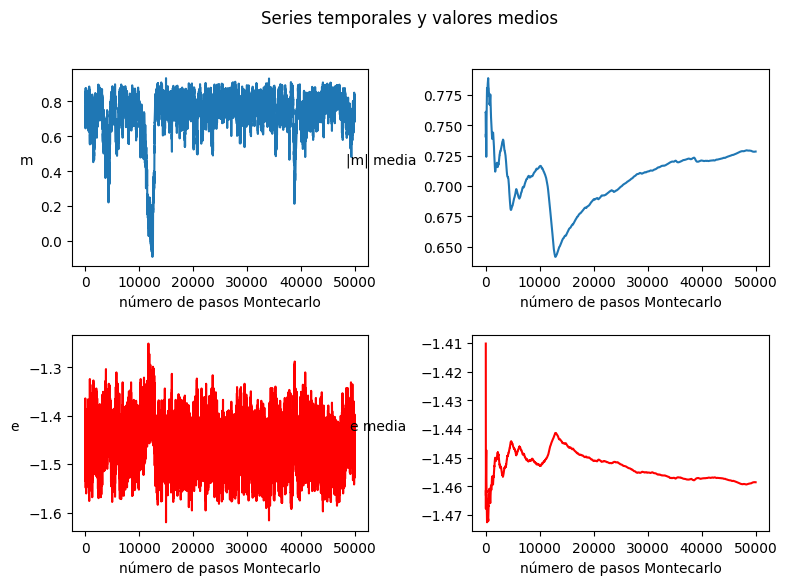

In [ ]:
L = 32
L2 = L * 2*L
T= 1.5
beta = 1 / T

Nequilibrio = 1000                                                               # Value chosen based on the previous results
npromedio = 50000                                                                # Tentative number of steps for calculating averages

prob = np.zeros(7)
prob[2]=np.exp(-2 * beta)
prob[6]=np.exp(-6 * beta)

S = np.ones((L, 2*L), dtype = int)                                                 # Initial state
#S = 2 * np.random.randint(2, size = (L, 2*L)) - 1

S = metropolisTermo_hexagonal(S, prob, Nequilibrio)                                        # Thermalization

m = np.zeros(npromedio)                                                          # Store magnetization and energy as functions of the step
e = np.zeros(npromedio)

m[0] = np.mean(S)                                                                 # Initial values
e[0] = h(S)

mmedia = [abs(m[0])]                                                              # Running averages of absolute magnetization and energy
emedia = [e[0]]

# Generate time series and update the running averages at each step
for n in tqdm(range(1, npromedio)):
    S, dm, de = metropolis_hexagonal(S, prob)
    m[n] = m[n - 1] + dm
    e[n] = e[n - 1] + de
    mmedia.append((n * mmedia[n - 1] + abs(m[n])) / (n + 1))
    emedia.append((n * emedia[n - 1] + e[n]) / (n + 1))

m = m
e = e
mmedia = np.array(mmedia)
emedia = np.array(emedia)

fig = plt.figure(figsize = (9, 6))
plt.subplots_adjust(wspace = 0.35, hspace = 0.35)
fig.suptitle('Time series and running averages')
plt.subplot(2, 2, 1)
plt.plot(m)
plt.ylabel('m', rotation = 0, labelpad = 10)
plt.xlabel('Monte Carlo steps')
plt.subplot(2, 2, 2)
plt.plot(mmedia)
plt.ylabel('mean |m|', rotation = 0, labelpad = 30)
plt.xlabel('Monte Carlo steps')
plt.subplot(2, 2, 3)
plt.plot(e, color = 'red')
plt.ylabel('e', rotation = 0, labelpad = 10)
plt.xlabel('Monte Carlo steps')
plt.subplot(2, 2, 4)
plt.plot(emedia, color = 'red')
plt.ylabel('mean e', rotation = 0, labelpad = 30)
plt.xlabel('Monte Carlo steps')
plt.show()

100%|██████████| 40/40 [1:17:53<00:00, 116.83s/it]


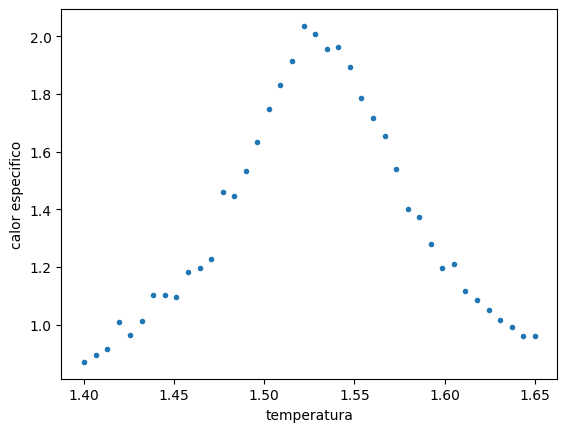

[[1.4        0.8702173 ]
 [1.40641026 0.89457319]
 [1.41282051 0.91508716]
 [1.41923077 1.00955698]
 [1.42564103 0.96216142]
 [1.43205128 1.01342133]
 [1.43846154 1.10369239]
 [1.44487179 1.10140392]
 [1.45128205 1.09625138]
 [1.45769231 1.18373859]
 [1.46410256 1.19717714]
 [1.47051282 1.22696798]
 [1.47692308 1.45808743]
 [1.48333333 1.4461508 ]
 [1.48974359 1.53251455]
 [1.49615385 1.63150735]
 [1.5025641  1.74676163]
 [1.50897436 1.8290996 ]
 [1.51538462 1.91438551]
 [1.52179487 2.03576894]
 [1.52820513 2.0081892 ]
 [1.53461538 1.95636178]
 [1.54102564 1.96134549]
 [1.5474359  1.89346429]
 [1.55384615 1.78596649]
 [1.56025641 1.71691135]
 [1.56666667 1.65495834]
 [1.57307692 1.53777368]
 [1.57948718 1.39955233]
 [1.58589744 1.37440524]
 [1.59230769 1.27836251]
 [1.59871795 1.19611584]
 [1.60512821 1.20832997]
 [1.61153846 1.11764574]
 [1.61794872 1.08664781]
 [1.62435897 1.04876216]
 [1.63076923 1.01594777]
 [1.63717949 0.99258679]
 [1.64358974 0.9587886 ]
 [1.65       0.95871278]]

In [ ]:
L = 32                                                                        # Choose L
L2 = L * 2*L

Tini = 1.4                                                                       # Choose the initial and final temperatures and the spacing, or define your own temperature list
Tfinal = 1.65                                                                     # Alternatively, use Ts = np.linspace(Tini, Tfinal, divisiones)
divisiones = 40

centro = 1.534
#delta = 0.02   # width of the fine interval
#T_fino = np.linspace(centro - delta, centro + delta, 6)

T_grueso = np.linspace(Tini, Tfinal, divisiones)

#temperaturas = np.unique(np.concatenate([T_grueso, T_fino]))
temperaturas = T_grueso
betas = 1 / temperaturas

factor = 10000                                                                  # Integer factor used to scale the total number of steps

nequilibriolejos = int(5 * factor)                                                   # Adjust these values; they are all set to 1 here
npromediolejos = int(10 * factor)
nequilibriocerca = int(50 * factor)
npromediocerca = int(100 * factor)

c = []
prob = np.zeros(7)

S = np.ones((L, 2*L), dtype = int)                                                # This initial condition assumes the simulation starts at low temperature; adapt it if needed
#S = 2 * np.random.randint(2, size = (L, 2*L)) - 1

for beta in tqdm(betas):

  prob[2]=np.exp(-2 * beta)
  prob[6]=np.exp(-6 * beta)                                                     # Set this according to how dE maps to indices in the probability vector

                                                                      # Adjust this based on the approximate location of the susceptibility maximum; some trial runs may be needed

  if abs(1 / beta - centro) < 0.04:                                              # Move the interval center to the maximum for each L
    nequilibrio = nequilibriocerca                                              # Choose step counts according to the distance from the center; 0.5 is a tentative threshold
    npromedio = npromediocerca                                                  # Refine how the number of steps is adapted if needed
  else:
    nequilibrio = nequilibriolejos
    npromedio = npromediolejos

  S = metropolisTermo_hexagonal(S, prob, nequilibrio)                                     # Thermalize

  c_calc = metropolisC_hexagonal(S, prob, npromedio,beta)                         # Measure mean absolute magnetization, mean energy,
                                                                                # and the variances of absolute magnetization and energy
  c.append(c_calc)


plt.scatter(temperaturas,c,marker='.')
plt.ylabel('specific heat')
plt.xlabel('temperature')
plt.show()

print(np.transpose([temperaturas, c]))

In [ ]:
print(temperaturas[np.argmax(c)])

1.5346153846153845


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
For L = 16, T_c = 1.5831268117017963 ± 0.0009339358656686338
For L = 32, T_c = 1.5536957927493884 ± 0.0011920887310248778
For L = 64, T_c = 1.55394336698486 ± 0.011600467567408963


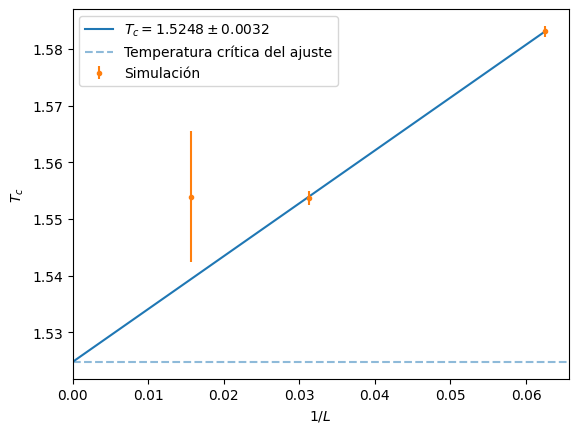

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

folder = "/content/drive/MyDrive/Red hexagonal/"   # Folder containing the files

# Load all files named L=XX.txt
filenames = sorted([f for f in os.listdir(folder)
                    if f.startswith("L=") and f.endswith("_hexa.txt")])

temps = {}
chis = {}

for filename in filenames:
    data = np.loadtxt(folder + filename, delimiter=',')

    temp_label = filename.split('=')[1].split('_')[0]  # Extracts 16, 30, 75, ...
    temps[temp_label] = data[:, 0]
    chis[temp_label] = data[:, 1]


# Quadratic fit for each L
def cuad2(x, a, x_0, c):
    return a*(x - x_0)**2 + c

Ls = np.array([])
Tcs = np.array([])
sigmasTc = np.array([])

for L in temps.keys():
    temp, chi = temps[L], chis[L]
    popt, cov = curve_fit(cuad2, temp, chi, p0=[-30000, 0, 0])

    a, x_0, c = popt
    uncertainty_x_0 = np.sqrt(cov[1, 1])

    print(f"For L = {L}, T_c = {x_0} \u00b1 {uncertainty_x_0}")

    Ls = np.append(Ls, int(L))
    Tcs = np.append(Tcs, x_0)
    sigmasTc = np.append(sigmasTc, uncertainty_x_0)

# Linear fit
def lineal(x, a, b):
    return a*x + b

popt, cov = curve_fit(lineal, 1/Ls, Tcs, sigma=sigmasTc)

T_c = popt[1]
uncertainty_Tc = np.sqrt(cov[1, 1])


# Plot the results
x = np.linspace(100000, 16, 200)

plt.plot(1/x, lineal(1/x, *popt),
         label=f'$T_c = {T_c:.4f} \\pm {uncertainty_Tc:.4f}$')

plt.errorbar(1/Ls, Tcs, yerr=sigmasTc, fmt='.',label='Simulation')

plt.axhline(T_c, linestyle='--', alpha=0.5, label='Critical temperature from the fit')

plt.xlabel("$1/L$")
plt.ylabel("$T_c$")
plt.xlim(0, None)
plt.legend()
plt.show()